## Compare transports between control and basal/iceberg experiments

Used some of Adele's scripts to calculate the transport in sigma 0 coordinates over the 1000m isobath. The scripts are located in the folder `PBS-script-code`. These are run each month and the output is in `/g/data/x77/cy8964/Post_Process/access-om2/##EXPT##` in monthly files. 

Recommend a XXLarge ARE session on Gadi if generating the compiled netcdf files for the first time.

In [1]:
%matplotlib inline

# import cosima_cookbook as cc

import intake
from access_nri_intake.source.builders import AccessOm2Builder

import matplotlib.pyplot as plt
import netCDF4 as nc
import xarray as xr
import numpy as np
from dask.distributed import Client
import cmocean as cm
from matplotlib import gridspec
from collections import OrderedDict

import logging
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)



In [2]:
client = Client(threads_per_worker=1, memory_limit="35GB", silence_logs=logging.ERROR)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 28
Total threads: 28,Total memory: 912.70 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38941,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42983,Total threads: 1
Dashboard: /proxy/37257/status,Memory: 32.60 GiB
Nanny: tcp://127.0.0.1:42857,


### Converted to intake catalog:

In [3]:
# add experiments to my own intake:

# - control:
path_ctrl = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath"

# - basal No Gade: GPC029 (Basal)   
path_noBG = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb'

# - basal Gade Brine: GPC062 (Basal_LH_Brine)    
path_BGB = '/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine'
# path_BGB = '/scratch/e14/fbd581/access-om2/fbd581/access-om2/archive/01deg_jra55_ryf9091_21mbath_basal'

### SOFIA meltwater perturbation expts:
# - control:
path_ctrl_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_21mbath_sofia_ssp126"

path_ctrl_antwater = "/scratch/e14/fbd581/access-om2/fbd581/access-om2/archive/01deg_jra55_ryf9091_21mbath_sofia_antwater-d0ea3a2d"

# - basal No Gade: GPC029 (Basal)   
path_noBG_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_sofia_ssp126"

# - basal Gade Brine: GPC062 (Basal_LH_Brine)    
path_BGB_sofia = "/g/data/ik11/outputs/access-om2-01/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126"

path_BGB_antwater = "/scratch/e14/fbd581/access-om2/fbd581/access-om2/archive/01deg_jra55_ryf9091_21mbath_basal_sofia_antwater_SSSrestoring-c1fb6bf0"
path_testSSS = "/scratch/e14/fbd581/access-om2/fbd581/access-om2/archive/01deg_jra55_ryf9091_21mbath_testSSSrestoring-adab07c6"

# new control runs with Gadel line:
path_ctrl_BG = "/scratch/e14/fbd581/access-om2/fbd581/access-om2/archive/01deg_jra55_ryf9091_21mbath_Gade-914fd6e4"
path_ctrl_BG_antwater = "/scratch/e14/fbd581/access-om2/fbd581/access-om2/archive/01deg_jra55_ryf9091_21mbath_Gade_sofia_antwater-383eae28"
path_ctrl_antwater_BG = "/scratch/e14/fbd581/access-om2/fbd581/access-om2/archive/01deg_jra55_ryf9091_21mbath_sofia_antwater_Gade-160c9273"


In [4]:
cat = intake.open_esm_datastore(
    "./DSW_control.json",
    columns_with_iterables=["variable"] 
)
# ds = cat.search(variable="temp").to_dask()

cat_noBG = intake.open_esm_datastore(
    "./Basal_noGade.json",
    columns_with_iterables=["variable"] 
)

# cat_BG = intake.open_esm_datastore(
#     "./Basal_LH.json",
#     columns_with_iterables=["variable"] 
# )

cat_BGB = intake.open_esm_datastore(
    "./Basal_LH_Brine.json",
    columns_with_iterables=["variable"] 
)

cat_sofia = intake.open_esm_datastore(
    "./DSW_control_sofia.json",
    columns_with_iterables=["variable"] 
)

cat_noBG_sofia = intake.open_esm_datastore(
    "./Basal_sofia.json",
    columns_with_iterables=["variable"] 
)

cat_BGB_sofia = intake.open_esm_datastore(
    "./Basal_LH_Brine_sofia.json",
    columns_with_iterables=["variable"] 
)

cat_antwater = intake.open_esm_datastore(
    "./DSW_control_antwater.json",
    columns_with_iterables=["variable"] 
)

cat_BGB_antwater = intake.open_esm_datastore(
    "./Basal_LH_Brine_antwater.json",
    columns_with_iterables=["variable"] 
)

# cat_SSStest = intake.open_esm_datastore(
#     "./DSW_control_noSSSrest.json",
#     columns_with_iterables=["variable"] 
# )

cat_ctrlBG = intake.open_esm_datastore(
    "./DSW_control_LH.json",
    columns_with_iterables=["variable"] 
)

cat_ctrlBG_antwater = intake.open_esm_datastore(
    "./DSW_control_LH_antwater.json",
    columns_with_iterables=["variable"] 
)

cat_ctrl_antwater_BG = intake.open_esm_datastore(
    "./DSW_control_antwater_LH.json",
    columns_with_iterables=["variable"] 
)

In [5]:
# Make sure these match the available restarts:
start_time='1917-01-01'
end_time='1919-12-31'
time_slice = slice(start_time,end_time)
lat_slice  = slice(-80,-59)
lat_range  = slice(-90,-59)

outpath = '/g/data/e14/fbd581/Basal_Pedro_project/SWMT/'

### Make database (cosima cookbook -> deprecated)

In [6]:
session_name = '/g/data/e14/fbd581/model_data/access-om2/basal_melt_MOM5_MW_pt2.db'
master_session = cc.database.create_session(session_name)


control = '01deg_jra55v13_ryf9091_21mbath' #01deg_jra55v13_ryf9091_DSW'
control_sofia = '01deg_jra55v13_ryf9091_21mbath_sofia_ssp126' #01deg_jra55v13_ryf9091_DSW'

basal_nogade = '01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb'
basal_nogade_sofia = '01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_sofia_ssp126'

basal_gade_brine = '01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_rep'
basal_gade_brine_sofia = '01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126'

control_antwater = "01deg_jra55_ryf9091_21mbath_sofia_antwater-d0ea3a2d"
basal_gade_brine_antwater = "01deg_jra55_ryf9091_21mbath_basal_sofia_antwater_SSSrestoring-c1fb6bf0"


NameError: name 'cc' is not defined

### First plot contour

In [20]:
### Load Adele's isobath contour
isobath_depth = 1000
outfile = '/g/data/x77/cy8964/Post_Process/access-om2'+'/Antarctic_slope_contour_'+str(isobath_depth)+'m.npz'
data = np.load(outfile)
mask_y_transport = data['mask_y_transport']
mask_x_transport = data['mask_x_transport']

In [21]:
 cat.search(variable='ht', file_id='ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700').keys()

['ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700']

In [31]:
aa=cat.search(variable='ht', file_id='ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700').to_dask()


ESMDataSourceError: Failed to load dataset with key='ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700'
                 You can use `cat['ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700'].df` to inspect the assets/files for this key.
                 

In [27]:
ht = cat.search(variable='ht', file_id='ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700').to_dask()#xarray_open_kwargs={'decode_timedelta':False})#,'chunks' :{'grid_yt_ocean' : 600,'grid_xt_ocean' : 800,}})
# ht = ht['ht'].sel(yt_ocean=lat_range)
# yt_ocean = cat.search(variable='yt_ocean', file_id='ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700').to_dask(xarray_open_kwargs={'decode_timedelta':False,'chunks' :{'grid_yt_ocean' : 600,'grid_xt_ocean' : 800,}})
# yt_ocean = yt_ocean['yt_ocean']
# xt_ocean = cat.search(variable='xt_ocean', file_id='ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700').to_dask(xarray_open_kwargs={'decode_timedelta':False,'chunks' :{'grid_yt_ocean' : 600,'grid_xt_ocean' : 800,}})
# xt_ocean = xt_ocean['xt_ocean']
# yt_ocean = yt_ocean.sel(yt_ocean=lat_range)




ESMDataSourceError: Failed to load dataset with key='ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700'
                 You can use `cat['ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700'].df` to inspect the assets/files for this key.
                 

In [ ]:
land_mask = np.squeeze(ht.values)*0
land_mask[np.isnan(land_mask)] = 1
land_mask = np.where(land_mask==1,land_mask,np.nan)
land_mask_masked = np.ma.masked_where((land_mask==0),land_mask)
# make land go all the way to -90S:
land_mask_lat = ht.yt_ocean.values
land_mask_lat[0] = -90



In [ ]:
fig, axes = plt.subplots(figsize = (12,4))
ht.plot(ax = axes, cmap = cm.cm.deep)
axes.contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport)+np.abs(mask_y_transport),colors = 'k')
axes.set_title('1000m isobath contour')
#plt.savefig('contour.png', dpi = 300)

### Load and plot maps of Age anomalies

need to convert from CC to intake!

In [ ]:
# now plot age anomaly instead

# select out bottom values:
start_time = '1917-01-01'
end_time = '1919-12-31'
time_slice = slice(start_time,end_time)

age_ctrl = cc.querying.getvar(control, 'age_global',master_session,start_time = start_time,
                            end_time = end_time).sel(time = time_slice,yt_ocean=lat_range)
age_BGB = cc.querying.getvar(basal_gade_brine, 'age_global',master_session,start_time = start_time,
                            end_time = end_time).sel(time = time_slice,yt_ocean=lat_range)
age_noBG = cc.querying.getvar(basal_nogade, 'age_global',master_session, frequency='1 monthly',start_time = start_time,
                            end_time = end_time).sel(time = time_slice,yt_ocean=lat_range)



In [ ]:
age_ctrl_s = cc.querying.getvar(control_sofia, 'age_global',master_session,start_time = start_time,
                            end_time = end_time).sel(time = time_slice,yt_ocean=lat_range)
age_BGB_s = cc.querying.getvar(basal_gade_brine_sofia, 'age_global',master_session,start_time = start_time,
                            end_time = end_time).sel(time = time_slice,yt_ocean=lat_range)
age_noBG_s = cc.querying.getvar(basal_nogade_sofia, 'age_global',master_session, frequency='1 monthly',start_time = start_time,
                            end_time = end_time).sel(time = time_slice,yt_ocean=lat_range)

In [ ]:
# age_ctrl_a = cc.querying.getvar(control_antwater, 'age_global',master_session)#,start_time = start_time,
                            # end_time = end_time).sel(time = time_slice,yt_ocean=lat_range)
age_BGB_s = cc.querying.getvar(basal_gade_brine_antwater, 'age_global',master_session,start_time = start_time,
                            end_time = end_time).sel(time = time_slice,yt_ocean=lat_range)


In [ ]:
day_in_month = age_BGB.time.dt.days_in_month
age_ctrl_mean = (age_ctrl*day_in_month).sum('time')/day_in_month.sum('time')
age_BGB_mean = (age_BGB*day_in_month).sum('time')/day_in_month.sum('time')
age_noBG_mean = (age_noBG*day_in_month).sum('time')/day_in_month.sum('time')


In [ ]:
age_ctrl_s_mean = (age_ctrl_s*day_in_month).sum('time')/day_in_month.sum('time')
age_BGB_s_mean = (age_BGB_s*day_in_month).sum('time')/day_in_month.sum('time')
age_noBG_s_mean = (age_noBG_s*day_in_month).sum('time')/day_in_month.sum('time')


In [ ]:
age_ctrl_mean = age_ctrl_mean.load()
age_BGB_mean = age_BGB_mean.load()
age_noBG_mean = age_noBG_mean.load()

In [ ]:

age_ctrl_s_mean = age_ctrl_s_mean.load()
age_BGB_s_mean = age_BGB_s_mean.load()
age_noBG_s_mean = age_noBG_s_mean.load()

In [ ]:
depth_array = age_ctrl.isel(time =0) * 0 + age_ctrl.st_ocean
max_depth = depth_array.max(dim = 'st_ocean', skipna= True)

bottom_age_ctrl = age_ctrl_mean.where(depth_array.st_ocean >= max_depth)
bottom_age_ctrl = bottom_age_ctrl.sum(dim = 'st_ocean')
bottom_age_ctrl = bottom_age_ctrl.load()

bottom_age_noBG = age_noBG_mean.where(depth_array.st_ocean >= max_depth)
bottom_age_noBG = bottom_age_noBG.sum(dim = 'st_ocean')
bottom_age_noBG = bottom_age_noBG.load()

bottom_age_BGB = age_BGB_mean.where(depth_array.st_ocean >= max_depth)
bottom_age_BGB = bottom_age_BGB.sum(dim = 'st_ocean')
bottom_age_BGB = bottom_age_BGB.load()

In [ ]:
bottom_age_ctrl_s = age_ctrl_s_mean.where(depth_array.st_ocean >= max_depth)
bottom_age_ctrl_s = bottom_age_ctrl_s.sum(dim = 'st_ocean')
bottom_age_ctrl_s = bottom_age_ctrl_s.load()

bottom_age_noBG_s = age_noBG_s_mean.where(depth_array.st_ocean >= max_depth)
bottom_age_noBG_s = bottom_age_noBG_s.sum(dim = 'st_ocean')
bottom_age_noBG_s = bottom_age_noBG_s.load()

bottom_age_BGB_s = age_BGB_s_mean.where(depth_array.st_ocean >= max_depth)
bottom_age_BGB_s = bottom_age_BGB_s.sum(dim = 'st_ocean')
bottom_age_BGB_s = bottom_age_BGB_s.load()

In [ ]:
bottom_age_ctrl_a = age_ctrl_a_mean.where(depth_array.st_ocean >= max_depth)
bottom_age_ctrl_a = bottom_age_ctrl_a.sum(dim = 'st_ocean')
bottom_age_ctrl_a = bottom_age_ctrl_a.load()

bottom_age_BGB_a = age_BGB_a_mean.where(depth_array.st_ocean >= max_depth)
bottom_age_BGB_a = bottom_age_BGB_a.sum(dim = 'st_ocean')
bottom_age_BGB_a = bottom_age_BGB_a.load()

In [ ]:
yt_ocean = cc.querying.getvar(control, 'yt_ocean',master_session, n=1, ncfile = 'ocean_grid.nc')
xt_ocean = cc.querying.getvar(control, 'xt_ocean',master_session, n=1, ncfile = 'ocean_grid.nc')
yt_ocean = yt_ocean.sel(yt_ocean=lat_range)


fig, axes = plt.subplots(figsize = (12,4))
(bottom_age_BGB-bottom_age_ctrl).plot(ax = axes, cmap = cm.cm.balance, cbar_kwargs = {'label':'Age anomaly (yrs)'}, vmax = 20, vmin = -20)
axes.contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport)+np.abs(mask_y_transport),colors = 'k')
axes.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='dimgrey',zorder=2,)
axes.set_title('1000m isobath contour')


In [ ]:
fig, axes = plt.subplots(figsize = (12,4))
(bottom_age_ctrl).plot(ax = axes, cmap = cm.cm.balance, cbar_kwargs = {'label':'Age (yrs)'}, vmax = 20, vmin = 0)
axes.contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport)+np.abs(mask_y_transport),colors = 'k')
axes.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='dimgrey',zorder=2,)
axes.set_title('1000m isobath contour - control')

In [ ]:
### do one figure with all bottom age maps: partI and II
figdir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'

# fig = plt.figure(figsize = (12,10),dpi = 200)
fig, ax  = plt.subplots(nrows=3, ncols=2, figsize = (16,14))

(bottom_age_ctrl).plot(ax = ax[0,0], cmap = cm.cm.balance, cbar_kwargs = {'label':'Age (yrs)'}, vmax = 20, vmin = 0)
ax[0,0].contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport)+np.abs(mask_y_transport),colors = 'k')
ax[0,0].contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='dimgrey',zorder=2,)
ax[0,0].set_title('1000m isobath contour: control')

(bottom_age_ctrl_s).plot(ax = ax[0,1], cmap = cm.cm.balance, cbar_kwargs = {'label':'Age (yrs)'}, vmax = 20, vmin = 0)
ax[0,1].contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport)+np.abs(mask_y_transport),colors = 'k')
ax[0,1].contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='dimgrey',zorder=2,)
ax[0,1].set_title('1000m isobath contour: control_sofia')

(bottom_age_noBG).plot(ax = ax[1,0], cmap = cm.cm.balance, cbar_kwargs = {'label':'Age (yrs)'}, vmax = 20, vmin = 0)
ax[1,0].contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport)+np.abs(mask_y_transport),colors = 'k')
ax[1,0].contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='dimgrey',zorder=2,)
ax[1,0].set_title('1000m isobath contour: basal ')

(bottom_age_noBG_s).plot(ax = ax[1,1], cmap = cm.cm.balance, cbar_kwargs = {'label':'Age (yrs)'}, vmax = 20, vmin = 0)
ax[1,1].contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport)+np.abs(mask_y_transport),colors = 'k')
ax[1,1].contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='dimgrey',zorder=2,)
ax[1,1].set_title('1000m isobath contour: basal_sofia')

(bottom_age_BGB).plot(ax = ax[2,0], cmap = cm.cm.balance, cbar_kwargs = {'label':'Age (yrs)'}, vmax = 20, vmin = 0)
ax[2,0].contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport)+np.abs(mask_y_transport),colors = 'k')
ax[2,0].contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='dimgrey',zorder=2,)
ax[2,0].set_title('1000m isobath contour: basal_LH_brine')

(bottom_age_BGB_s).plot(ax = ax[2,1], cmap = cm.cm.balance, cbar_kwargs = {'label':'Age (yrs)'}, vmax = 20, vmin = 0)
ax[2,1].contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport)+np.abs(mask_y_transport),colors = 'k')
ax[2,1].contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='dimgrey',zorder=2,)
ax[2,1].set_title('1000m isobath contour: basal_LH_brine_sofia')

plt.savefig(figdir+'Age_annual_yr17-20_ctrlxSOFIA.png',bbox_inches='tight',dpi=300)


In [ ]:
### do one figure with all bottom age maps: partI and II
figdir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'

# fig = plt.figure(figsize = (12,10),dpi = 200)
fig, ax  = plt.subplots(nrows=3, ncols=2, figsize = (16,14))

(bottom_age_ctrl).plot(ax = ax[0,0], cmap = cm.cm.balance, cbar_kwargs = {'label':'Age (yrs)'}, vmax = 20, vmin = 0)
ax[0,0].contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport)+np.abs(mask_y_transport),colors = 'k')
ax[0,0].contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='dimgrey',zorder=2,)
ax[0,0].set_title('1000m isobath contour: control')

(bottom_age_ctrl_s-bottom_age_ctrl).plot(ax = ax[0,1], cmap = cm.cm.balance, cbar_kwargs = {'label':'Age (yrs)'}, vmax = 3, vmin = -3)
ax[0,1].contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport)+np.abs(mask_y_transport),colors = 'k')
ax[0,1].contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='dimgrey',zorder=2,)
ax[0,1].set_title('1000m isobath contour: control - control_sofia')

(bottom_age_noBG).plot(ax = ax[1,0], cmap = cm.cm.balance, cbar_kwargs = {'label':'Age (yrs)'}, vmax = 20, vmin = 0)
ax[1,0].contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport)+np.abs(mask_y_transport),colors = 'k')
ax[1,0].contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='dimgrey',zorder=2,)
ax[1,0].set_title('1000m isobath contour: basal ')

(bottom_age_noBG_s-bottom_age_noBG).plot(ax = ax[1,1], cmap = cm.cm.balance, cbar_kwargs = {'label':'Age (yrs)'}, vmax = 3, vmin = -3)
ax[1,1].contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport)+np.abs(mask_y_transport),colors = 'k')
ax[1,1].contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='dimgrey',zorder=2,)
ax[1,1].set_title('1000m isobath contour: basal - basal_sofia')

(bottom_age_BGB).plot(ax = ax[2,0], cmap = cm.cm.balance, cbar_kwargs = {'label':'Age (yrs)'}, vmax = 20, vmin = 0)
ax[2,0].contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport)+np.abs(mask_y_transport),colors = 'k')
ax[2,0].contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='dimgrey',zorder=2,)
ax[2,0].set_title('1000m isobath contour: basal_LH_brine')

(bottom_age_BGB_s-bottom_age_BGB).plot(ax = ax[2,1], cmap = cm.cm.balance, cbar_kwargs = {'label':'Age (yrs)'}, vmax = 3, vmin = -3)
ax[2,1].contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport)+np.abs(mask_y_transport),colors = 'k')
ax[2,1].contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='dimgrey',zorder=2,)
ax[2,1].set_title('1000m isobath contour: basal_LH_brine - basal_LH_brine_sofia')

plt.savefig(figdir+'Age_annual_yr17-20_SOFIA-ctrl_anom.png',bbox_inches='tight',dpi=300)


In [ ]:
print(figdir+'Age_annual_yr17-20_ctrlxSOFIA_anom.png')

### Make nicer y axis than `contour_index` by loading in lon/lat/distance of contour

according to cosima recipes https://nbviewer.org/github/claireyung/cosima-recipes/blob/master/DocumentedExamples/Cross-contour_transport.ipynb

In [9]:
mask_y_transport = data['mask_y_transport']
mask_x_transport = data['mask_x_transport']
mask_y_transport_numbered = data['mask_y_transport_numbered']
mask_x_transport_numbered = data['mask_x_transport_numbered']

# yt_ocean = cc.querying.getvar(expt,'yt_ocean',session,n=1)
# yt_ocean = yt_ocean.sel(yt_ocean=lat_range)
# yu_ocean = cc.querying.getvar(expt,'yu_ocean',session,n=1)
# yu_ocean = yu_ocean.sel(yu_ocean=lat_range)
# xt_ocean = cc.querying.getvar(expt,'xt_ocean',session,n=1)
# xu_ocean = cc.querying.getvar(expt,'xu_ocean',session,n=1)
###-replace by inttake below:
yt_ocean = cat.search(variable='yt_ocean', file_id='ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700').to_dask(xarray_open_kwargs={'decode_timedelta':False,'chunks' :{'grid_yt_ocean' : 600,'grid_xt_ocean' : 800,}})
yu_ocean = cat.search(variable='yu_ocean', file_id='ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700').to_dask(xarray_open_kwargs={'decode_timedelta':False,'chunks' :{'grid_yt_ocean' : 600,'grid_xt_ocean' : 800,}})
yt_ocean = yt_ocean.sel(yt_ocean=lat_range)
yu_ocean = yu_ocean.sel(yu_ocean=lat_range)
xt_ocean = cat.search(variable='xt_ocean', file_id='ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700').to_dask(xarray_open_kwargs={'decode_timedelta':False,'chunks' :{'grid_yt_ocean' : 600,'grid_xt_ocean' : 800,}})
xu_ocean = cat.search(variable='xu_ocean', file_id='ocean.fx.xt_ocean:3600.xu_ocean:3600.yt_ocean:2700.yu_ocean:2700').to_dask(xarray_open_kwargs={'decode_timedelta':False,'chunks' :{'grid_yt_ocean' : 600,'grid_xt_ocean' : 800,}})


# Convert contour masks to data arrays, so we can multiply them later.
# We need to ensure the lat lon coordinates correspond to the actual data location:
#       The y masks are used for vhrho, so like vhrho this should have dimensions (yu_ocean, xt_ocean).
#       The x masks are used for uhrho, so like uhrho this should have dimensions (yt_ocean, xu_ocean).
#       However the actual name will always be simply y_ocean/x_ocean irrespective of the variable
#       to make concatenation of transports in both direction and sorting possible.

mask_x_transport = xr.DataArray(mask_x_transport, coords = [yt_ocean['yt_ocean'], xu_ocean['xu_ocean']], dims=['y_ocean', 'x_ocean'])
mask_y_transport = xr.DataArray(mask_y_transport, coords = [yu_ocean['yu_ocean'], xt_ocean['xt_ocean']], dims=['y_ocean', 'x_ocean'])
mask_x_transport_numbered = xr.DataArray(mask_x_transport_numbered, coords = [yt_ocean['yt_ocean'], xu_ocean['xu_ocean']], dims=['y_ocean', 'x_ocean'])
mask_y_transport_numbered = xr.DataArray(mask_y_transport_numbered, coords = [yu_ocean['yu_ocean'], xt_ocean['xt_ocean']], dims=['y_ocean', 'x_ocean'])

# ### Stack contour data into 1D

# Create the contour order data-array. Note that in this procedure the x-grid counts have x-grid
#   dimensions and the y-grid counts have y-grid dimensions, but these are implicit, the dimension 
#   *names* are kept general across the counts, the generic y_ocean, x_ocean, so that concatening works
#   but we dont double up with numerous counts for one lat/lon point.

# stack contour data into 1d:
mask_x_numbered_1d = mask_x_transport_numbered.stack(contour_index = ['y_ocean', 'x_ocean'])
mask_x_numbered_1d = mask_x_numbered_1d.where(mask_x_numbered_1d > 0, drop = True)
mask_y_numbered_1d = mask_y_transport_numbered.stack(contour_index = ['y_ocean', 'x_ocean'])
mask_y_numbered_1d = mask_y_numbered_1d.where(mask_y_numbered_1d > 0, drop = True)
contour_ordering = xr.concat((mask_x_numbered_1d,mask_y_numbered_1d), dim = 'contour_index')
contour_ordering = contour_ordering.sortby(contour_ordering)
contour_index_array = np.arange(1,len(contour_ordering)+1)

# get lat and lon along contour, useful for plotting later:
lat_along_contour = contour_ordering.y_ocean
lon_along_contour = contour_ordering.x_ocean
# don't need the multi-index anymore, replace with contour count
lat_along_contour.coords['contour_index'] = contour_index_array
lon_along_contour.coords['contour_index'] = contour_index_array



In [11]:
# ## save distance - this takes time so instead load result in next cell

# dxu = cc.querying.getvar(expt,'dxu',session,ncfile = 'ocean_grid.nc',n=1)
# dxu = dxu.sel(yu_ocean = lat_range)
# dyt = cc.querying.getvar(expt,'dyt',session,ncfile = 'ocean_grid.nc',n=1)
# dyt = dyt.sel(yt_ocean = lat_range)
# num_points = len(lat_along_contour)
# lat_t = cc.querying.getvar(expt,'geolat_t',session,ncfile = 'ocean_grid.nc',n=1)
# lat_t = lat_t.sel(yt_ocean = lat_range)
# lon_t = cc.querying.getvar(expt,'geolon_t',session,ncfile = 'ocean_grid.nc',n=1)
# lon_t = lon_t.sel(yt_ocean = lat_range)

# # if there is a bend in the contour, add the distance using length of diagonal, not sum of
# # 2 edges, to be more representative.    
# distance_along_contour = np.zeros((num_points))
# x_indices = np.sort(mask_x_transport_numbered.values[mask_x_transport_numbered.values>0])
# y_indices = np.sort(mask_y_transport_numbered.values[mask_y_transport_numbered.values>0])
# skip = False
# for count in range(1,num_points):
#     if skip == True:
#         skip = False
#         continue
#     if count in y_indices:
#         if count + 1 in y_indices:
#             # note dxu and dyt do no vary in x:
#             jj = np.where(mask_y_transport_numbered==count)[0]
#             distance_along_contour[count-1] = (dxu[jj,990])[0]
#         else:
#             jj0 = np.where(mask_y_transport_numbered==count)[0]
#             jj1 = np.where(mask_x_transport_numbered==count+1)[0]
#             diagonal_distance = 0.5*np.sqrt((dxu[jj0,990])[0]**2+\
#                 (dyt[jj1,990])[0]**2)
#             distance_along_contour[count-1] = diagonal_distance
#             distance_along_contour[count] = diagonal_distance
#             # skip to next count:
#             skip = True
#     # count in x_indices:
#     else:
#         if count + 1 in x_indices:
#             jj = np.where(mask_x_transport_numbered==count)[0]
#             distance_along_contour[count-1] = (dyt[jj,990])[0]
#         else:
#             jj0 = np.where(mask_x_transport_numbered==count)[0]
#             jj1 = np.where(mask_y_transport_numbered==count+1)[0]
#             diagonal_distance = 0.5*np.sqrt((dyt[jj0,990])[0]**2+\
#                 (dxu[jj1,990])[0]**2)
#             distance_along_contour[count-1] = diagonal_distance
#             distance_along_contour[count] = diagonal_distance
#             # skip to next count:
#             skip = True
# # fix last value:
# if distance_along_contour[-1] == 0:
#     count = count + 1
#     if count in y_indices:
#         jj = np.where(mask_y_transport_numbered==count)[0]
#         distance_along_contour[-1] = (dxu[jj,990])[0]
#     else:
#         jj = np.where(mask_x_transport_numbered==count)[0]
#         distance_along_contour[-1] = (dyt[jj,990])[0]

# # units are 10^3 km:
# distance_along_contour = np.cumsum(distance_along_contour)/1e3/1e3 
# #save_dir = '/g/data/x77/cy8964/Post_Process/access-om2/'
# #ds_latlondist = xr.Dataset({'distance_along_contour': distance_along_contour})
# #ds_latlondist.to_netcdf(save_dir+'1000m_isobath_contour_distance.nc')

In [12]:
distance_along_contour = xr.open_dataset('/g/data/x77/cy8964/Post_Process/access-om2/1000m_isobath_contour_distance.nc').distance_along_contour

In [13]:
#determine where to put lon tick marks
distance_indices = np.zeros(8)
for i in np.arange(100,len(lon_along_contour.values)):
    if (distance_indices[1]==0):
        if (lon_along_contour.values[i]>-240):
            distance_indices[1] = lon_along_contour.contour_index.values[i]
    if (distance_indices[2]==0):
        if (lon_along_contour.values[i]>-180):
            distance_indices[2] = lon_along_contour.contour_index.values[i]
    if (distance_indices[3]==0):
        if (lon_along_contour.values[i]>-120):
            distance_indices[3] = lon_along_contour.contour_index.values[i]
    if (distance_indices[4]==0):
        if lon_along_contour.values[i]>-60:
            distance_indices[4] = lon_along_contour.contour_index.values[i]
    if (distance_indices[5]==0):
        if (lon_along_contour.values[i]>0):
            distance_indices[5] = lon_along_contour.contour_index.values[i]
    if (distance_indices[6]==0):
        if (lon_along_contour.values[i]>60):
            distance_indices[6] = lon_along_contour.contour_index.values[i]
distance_indices[7] = len(lon_along_contour.contour_index.values)-1


## Save transport individual files together (time mean)

This section saves data as netcdfs to improve loading speed.

In [14]:
## Define intake catalog name ==> MAKE SURE THIS MATCH WITH EXPT BELOW AS DESIRED!!!
CAT = cat # control
#CAT = cat_noBG # Basal (noGade)
#CAT = cat_BGB # BasasLHBrine
#CAT = cat_sofia # control SSP126
#CAT = cat_noBG_sofia # Basal (noGade) SSP126
#CAT = cat_BGB_sofia # BasalLHBrine SSP126
#CAT = cat_antwater # control antwater
#CAT = cat_BGB_antwater # BasalLHBrine antwater
#CAT = cat_SSStest # no SSS restoring test
#CAT = cat_ctrlBG # controlLH
# CAT = cat_ctrlBG_antwater # controlLH antwater
#CAT = cat_ctrl_antwater_BG # control antwater_LH

## Define name of the expt (for output filename):
expt = "01deg_jra55v13_ryf9091_21mbath" # control
#expt = "01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb" # Basal (noGade)
#expt = "01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine" # BasasLHBrine
#expt = "01deg_jra55v13_ryf9091_21mbath_sofia_ssp126" # control SSP126
#expt = "01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_sofia_ssp126"  # Basal (noGade) SSP126
#expt = "01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126" # BasalLHBrine SSP126
#expt = "01deg_jra55_ryf9091_21mbath_sofia_antwater-d0ea"
#expt = "01deg_jra55_ryf9091_21mbath_basal_sofia_antwater_SSSrestoring-c1fb6bf0"
#expt = "01deg_jra55_ryf9091_21mbath_Gade"
# expt = "01deg_jra55_ryf9091_21mbath_Gade_sofia_antwater"
#expt = "01deg_jra55_ryf9091_21mbath_sofia_antwater_Gade"

In [15]:
def load_monthly_data (name,yr_start,yr_end):
    year_first = yr_start +'-01-01'
    year_last = yr_end +'-12-31'
    print(year_first, year_last)
    #get time data
    temp = CAT.search(variable='temp').to_dask(xarray_open_kwargs={'decode_timedelta':True,'chunks' :{'time' : 2,'st_ocean' : 14,'grid_yt_ocean' : 600,'grid_xt_ocean' : 800,}})
    # temp = temp.sel(time = slice('1900-01-01','1920-01-01'))  ## control
    temp = temp.sel(time = slice(str(year_first),str(year_last)))  ## noBG
    time_data = temp.time
    
    # load monthly saved transports as a time series

    # test = xr.open_mfdataset('/g/data/x77/cy8964/Post_Process/access-om2/'+name+
    #                          '/Antarctic_cross_slope/vol_trans_across_contour_1900_01.nc').vol_trans_across_contour_binned
    test = xr.open_mfdataset('/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/'+name+'_vol_trans_across_contour_1911_01.nc')#.vol_trans_across_contour_binned
    # print('/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/'+name+'_vol_trans_across_contour_1911_01.nc')
    vol_trans_across_contour_t = xr.zeros_like(test)
    vol_trans_across_contour_t  = vol_trans_across_contour_t.expand_dims({"time":time_data})
    count_days = 0
    # load 10 year (10 years x 12 months)
    # for j in np.arange(1900,1920):   # control
    print(int(yr_start),int(yr_end))
    for j in np.arange(int(yr_start),int(yr_end)):    # noBG
        for i in np.arange(1,13):
            filename='/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/'+name+'_vol_trans_across_contour_'+str(j)+'_'+str(i).zfill(2)+'.nc'
            print(filename)
            it = xr.open_mfdataset(filename)
            it.load()
            vol_trans_across_contour_t['vol_trans_across_contour_binned'][i+12*(j-int(yr_start))-1,:,:] = it.vol_trans_across_contour_binned 
            count_days = count_days + it.ndays.values
        print(j)
    return vol_trans_across_contour_t, count_days


In [16]:
# #### debug section:

# yr_start='1910'
# yr_end='1919'
# year_first = yr_start +'-01-01'
# year_last = yr_end +'-12-31'
# print(year_first, year_last)
# #get time data
# # temp = cc.querying.getvar(control,'temp',master_session)
# ## replace by intekae:
# temp = CAT.search(variable='temp').to_dask(xarray_open_kwargs={'decode_timedelta':True,'chunks' :{'time' : 2,'st_ocean' : 14,'grid_yt_ocean' : 600,'grid_xt_ocean' : 800,}})
# # temp = temp.sel(time = slice('1900-01-01','1920-01-01'))  ## control
# temp = temp.sel(time = slice(str(year_first),str(year_last)))  ## noBG
# time_data = temp.time

# # exptname='01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb'
# # i=1
# # j=1919
# # filename='/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/'+exptname+'_vol_trans_across_contour_'+str(j)+'_'+str(i).zfill(2)+'.nc'
# # print(filename)
# # it = xr.open_mfdataset(filename)


# # vol_trans_across_contour_t = xr.zeros_like(it)
# # vol_trans_across_contour_t
# # vol_trans_across_contour_t  = vol_trans_across_contour_t.expand_dims({"time":time_data})
# # vol_trans_across_contour_t.sel(time=(i+12*(j-1900)-1)) = it.vol_trans_across_contour_binned

# # vol_trans_across_contour_t['vol_trans_across_contour_binned'][0,:,:] = it.vol_trans_across_contour_binned


In [17]:
exptname='01deg_jra55v13_ryf9091_21mbath'
control_vol_trans_ctrl, ndays_ctrl = load_monthly_data(exptname,'1900','1920')


1900-01-01 1920-12-31


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "grid_yt_ocean" starting at index 600. This could degrade performance. Instead, consider rechunking after loading.
  d

1900 1920
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_21mbath_vol_trans_across_contour_1900_01.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_21mbath_vol_trans_across_contour_1900_02.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_21mbath_vol_trans_across_contour_1900_03.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_21mbath_vol_trans_across_contour_1900_04.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_21mbath_vol_trans_across_contour_1900_05.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_21mbath_vol_trans_across_contour_1900_06.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_21mbath_vol_trans_across_contour_1900_07.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ry

In [18]:
exptname='01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb'
control_vol_trans_noBG, ndays_noBG = load_monthly_data(exptname,'1900','1920')


1900-01-01 1920-12-31


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr

1900 1920
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_vol_trans_across_contour_1900_01.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_vol_trans_across_contour_1900_02.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_vol_trans_across_contour_1900_03.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_vol_trans_across_contour_1900_04.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_vol_trans_across_contour_1900_05.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_vol_trans_across_contour_1900_06.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_vol_trans_across_c

In [19]:
exptname='01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_rep'
control_vol_trans_BGB, ndays_BGB = load_monthly_data(exptname,'1900','1920')


1900-01-01 1920-12-31


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr

1900 1920
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_rep_vol_trans_across_contour_1900_01.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_rep_vol_trans_across_contour_1900_02.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_rep_vol_trans_across_contour_1900_03.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_rep_vol_trans_across_contour_1900_04.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_rep_vol_trans_across_contour_1900_05.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_rep_vol_trans_across_contour_1900_06.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_

In [20]:
exptname='01deg_jra55v13_ryf9091_21mbath_sofia_ssp126'
control_vol_trans_ctrl_s, ndays_ctrl_s = load_monthly_data(exptname,'1910','1920')


1910-01-01 1920-12-31


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr

1910 1920
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_21mbath_sofia_ssp126_vol_trans_across_contour_1910_01.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_21mbath_sofia_ssp126_vol_trans_across_contour_1910_02.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_21mbath_sofia_ssp126_vol_trans_across_contour_1910_03.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_21mbath_sofia_ssp126_vol_trans_across_contour_1910_04.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_21mbath_sofia_ssp126_vol_trans_across_contour_1910_05.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_21mbath_sofia_ssp126_vol_trans_across_contour_1910_06.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_21mbath_sofia_ssp126_vol_trans_across_contour_

In [21]:
exptname='01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_sofia_ssp126'
control_vol_trans_noBG_s, ndays_noBG_s = load_monthly_data(exptname,'1910','1920')


1910-01-01 1920-12-31


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr

1910 1920
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_sofia_ssp126_vol_trans_across_contour_1910_01.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_sofia_ssp126_vol_trans_across_contour_1910_02.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_sofia_ssp126_vol_trans_across_contour_1910_03.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_sofia_ssp126_vol_trans_across_contour_1910_04.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_sofia_ssp126_vol_trans_across_contour_1910_05.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_sofia_ssp126_vol_trans_across_contour_1910_06.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-con

In [22]:
exptname='01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126'
control_vol_trans_BGB_s, ndays_BGB_s = load_monthly_data(exptname,'1910','1920')


1910-01-01 1920-12-31


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "grid_yt_ocean" starting at index 600. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "grid_xt_ocean" starting at index 800. This could degrade performance. Instead, consider rechunking after loadin

1910 1920
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126_vol_trans_across_contour_1910_01.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126_vol_trans_across_contour_1910_02.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126_vol_trans_across_contour_1910_03.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126_vol_trans_across_contour_1910_04.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126_vol_trans_across_contour_1910_05.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126_vol_trans_across_contour_1910_06.nc
/g/data/e14/fbd581/Basal

In [23]:
exptname='01deg_jra55_ryf9091_21mbath_sofia_antwater-d0ea3a2d'
control_vol_trans_ctrl_a, ndays_ctrl_a = load_monthly_data(exptname,'1910','1920')


1910-01-01 1920-12-31


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "grid_yt_ocean" starting at index 600. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "grid_xt_ocean" starting at index 800. This could degrade performance. Instead, consider rechunking after loadin

1910 1920
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_sofia_antwater-d0ea3a2d_vol_trans_across_contour_1910_01.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_sofia_antwater-d0ea3a2d_vol_trans_across_contour_1910_02.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_sofia_antwater-d0ea3a2d_vol_trans_across_contour_1910_03.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_sofia_antwater-d0ea3a2d_vol_trans_across_contour_1910_04.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_sofia_antwater-d0ea3a2d_vol_trans_across_contour_1910_05.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_sofia_antwater-d0ea3a2d_vol_trans_across_contour_1910_06.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_2

In [24]:
exptname='01deg_jra55_ryf9091_21mbath_basal_sofia_antwater_SSSrestoring-c1fb6bf0'
control_vol_trans_BGB_a, ndays_BGB_a = load_monthly_data(exptname,'1910','1920')


1910-01-01 1920-12-31


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr

1910 1920
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_basal_sofia_antwater_SSSrestoring-c1fb6bf0_vol_trans_across_contour_1910_01.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_basal_sofia_antwater_SSSrestoring-c1fb6bf0_vol_trans_across_contour_1910_02.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_basal_sofia_antwater_SSSrestoring-c1fb6bf0_vol_trans_across_contour_1910_03.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_basal_sofia_antwater_SSSrestoring-c1fb6bf0_vol_trans_across_contour_1910_04.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_basal_sofia_antwater_SSSrestoring-c1fb6bf0_vol_trans_across_contour_1910_05.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_basal_sofia_antwater_SSSrestoring-c1fb6bf0_vol_tr

In [25]:
exptname='01deg_jra55_ryf9091_21mbath_Gade'
control_vol_trans_ctrlBG, ndays_ctrlBG = load_monthly_data(exptname,'1910','1920')


1910-01-01 1920-12-31


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr

1910 1920
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_Gade_vol_trans_across_contour_1910_01.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_Gade_vol_trans_across_contour_1910_02.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_Gade_vol_trans_across_contour_1910_03.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_Gade_vol_trans_across_contour_1910_04.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_Gade_vol_trans_across_contour_1910_05.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_Gade_vol_trans_across_contour_1910_06.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_Gade_vol_trans_across_contour_1910_07.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01d

In [26]:
exptname='01deg_jra55_ryf9091_21mbath_Gade_sofia_antwater'
control_vol_trans_ctrlBG_a, ndays_ctrlBG_a = load_monthly_data(exptname,'1910','1920')


1910-01-01 1920-12-31


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr

1910 1920
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_Gade_sofia_antwater_vol_trans_across_contour_1910_01.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_Gade_sofia_antwater_vol_trans_across_contour_1910_02.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_Gade_sofia_antwater_vol_trans_across_contour_1910_03.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_Gade_sofia_antwater_vol_trans_across_contour_1910_04.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_Gade_sofia_antwater_vol_trans_across_contour_1910_05.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_Gade_sofia_antwater_vol_trans_across_contour_1910_06.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_Gade_sofia_antwat

In [27]:
exptname='01deg_jra55_ryf9091_21mbath_sofia_antwater_Gade'
control_vol_trans_ctrl_a_BG, ndays_ctrl_a_BG = load_monthly_data(exptname,'1910','1920')


1910-01-01 1920-12-31


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "st_ocean" starting at index 14. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "grid_yt_ocean" starting at index 600. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(url, **xarray_open_kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.01/lib/python3.11/site-packages/intake_esm/source.py:101: UserWarning: The specified chunks separate the stored chunks along dimension "grid_xt_ocean" starting at index 800. This could degrade performance. Instead, consider rechunking after loadin

1910 1920
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_sofia_antwater_Gade_vol_trans_across_contour_1910_01.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_sofia_antwater_Gade_vol_trans_across_contour_1910_02.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_sofia_antwater_Gade_vol_trans_across_contour_1910_03.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_sofia_antwater_Gade_vol_trans_across_contour_1910_04.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_sofia_antwater_Gade_vol_trans_across_contour_1910_05.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_sofia_antwater_Gade_vol_trans_across_contour_1910_06.nc
/g/data/e14/fbd581/Basal_Pedro_project/cross-contour-processed/01deg_jra55_ryf9091_21mbath_sofia_antwater_Ga

In [28]:
#### doing annual average over last 3 years:
def av_last_3yr (array):
    array = array.sel(time = slice('1917-01-01','1919-12-31'))
    array_last_3yr = (array*array.time.dt.days_in_month).sum('time') * \
                        1/(array.time.dt.days_in_month).sum('time')
    return array_last_3yr

In [29]:
control_vol_trans_avg_ctrl = av_last_3yr(control_vol_trans_ctrl)

In [30]:
control_vol_trans_avg_ctrl_s = av_last_3yr(control_vol_trans_ctrl_s)

In [31]:
control_vol_trans_avg_ctrl_a = av_last_3yr(control_vol_trans_ctrl_a)

In [32]:
control_vol_trans_avg_noBG = av_last_3yr(control_vol_trans_noBG)

In [33]:
control_vol_trans_avg_noBG_s = av_last_3yr(control_vol_trans_noBG_s)

In [34]:
control_vol_trans_avg_BGB = av_last_3yr(control_vol_trans_BGB)

In [35]:
control_vol_trans_avg_BGB_s = av_last_3yr(control_vol_trans_BGB_s)

In [36]:
control_vol_trans_avg_BGB_a = av_last_3yr(control_vol_trans_BGB_a)

In [37]:
%%time
control_vol_trans_avg_ctrl.load()
control_vol_trans_avg_ctrl_s.load()
control_vol_trans_avg_noBG.load()
control_vol_trans_avg_noBG_s.load()
control_vol_trans_avg_BGB.load()
control_vol_trans_avg_BGB_s.load()
control_vol_trans_avg_ctrl_a.load()
control_vol_trans_avg_BGB_a.load()


CPU times: user 3min 24s, sys: 1min 9s, total: 4min 34s
Wall time: 13min


<xarray.Dataset> Size: 6MB
Dimensions:                          (isopycnal_bins: 128, contour_index: 6002)
Coordinates:
  * isopycnal_bins                   (isopycnal_bins) float64 1kB 1e+03 ... 1...
  * contour_index                    (contour_index) int64 48kB 1 2 ... 6002
Data variables:
    vol_trans_across_contour_binned  (isopycnal_bins, contour_index) float64 6MB ...
    ndays                            float64 8B 0.0

In [38]:
control_vol_trans_avg_ctrlBG = av_last_3yr(control_vol_trans_ctrlBG)
control_vol_trans_avg_ctrlBG_a = av_last_3yr(control_vol_trans_ctrlBG_a)
control_vol_trans_avg_ctrl_a_BG = av_last_3yr(control_vol_trans_ctrl_a_BG)

In [39]:
control_vol_trans_avg_ctrlBG.load()
control_vol_trans_avg_ctrlBG_a.load()
control_vol_trans_avg_ctrl_a_BG.load()


<xarray.Dataset> Size: 6MB
Dimensions:                          (isopycnal_bins: 128, contour_index: 6002)
Coordinates:
  * isopycnal_bins                   (isopycnal_bins) float64 1kB 1e+03 ... 1...
  * contour_index                    (contour_index) int64 48kB 1 2 ... 6002
Data variables:
    vol_trans_across_contour_binned  (isopycnal_bins, contour_index) float64 6MB ...
    ndays                            float64 8B 0.0

In [40]:
save_dir = '/g/data/e14/fbd581/Basal_Pedro_project/updated_git_basal_mom5-collaborative/basal_mom5-collaborative-project/notebooks/cross_contour/'
for i in np.arange(11):
    transport_arr = [control_vol_trans_avg_ctrl, control_vol_trans_avg_ctrl_s, control_vol_trans_avg_ctrl_a, 
                     control_vol_trans_avg_noBG, control_vol_trans_avg_noBG_s,
                     control_vol_trans_avg_BGB, control_vol_trans_avg_BGB_s, control_vol_trans_avg_BGB_a,
                     control_vol_trans_avg_ctrlBG, control_vol_trans_avg_ctrlBG_a, control_vol_trans_avg_ctrl_a_BG][i]
    name = ['control','control_ssp126','control_antwater',
            'basal_nogade','basal_nogade_ssp126','basal_gade_brine',
            'basal_gade_brine_ssp126','basal_gade_brine_antwater',
            'control_gade','control_gade_antwater','control_antwater_gade'][i]
    
    ds = xr.Dataset({'vol_trans_across_contour_binned_last_3yr': transport_arr.to_dataarray()})
    ds.to_netcdf(save_dir+name+'_vol_trans_across_contour_binned_last_3yr.nc')

## Transport cumulative sums for different density classes and sectors

Define in longitude space what the cut-off values for regions should be.


In [41]:
AdelieW = -280
AdelieE = -200
RossW = -200
RossE = -150
# WAW = -150
# WAE = -65
AmW = -150
AmE = -100
BeW = -100
BeE = -65

WeddellW = -65
WeddellE = 0
PrydzW = 0
PrydzE = 80

#### need to find corresponding contour indices for sectors

In [42]:
basin_indices = np.zeros(7)
for i in np.arange(100,len(lon_along_contour.values)):
    if (basin_indices[1]==0):
        if (lon_along_contour.values[i]>AdelieE):
            basin_indices[1] = lon_along_contour.contour_index.values[i]
    if (basin_indices[2]==0):
        if (lon_along_contour.values[i]>RossE):
            basin_indices[2] = lon_along_contour.contour_index.values[i]
    if (basin_indices[3]==0):
        if (lon_along_contour.values[i]>AmE):
            basin_indices[3] = lon_along_contour.contour_index.values[i]
    if (basin_indices[4]==0):
        if (lon_along_contour.values[i]>BeE):
            basin_indices[4] = lon_along_contour.contour_index.values[i]
    if (basin_indices[5]==0):
        if lon_along_contour.values[i]>WeddellE:
            basin_indices[5] = lon_along_contour.contour_index.values[i]
    if (basin_indices[6]==0):
        if (lon_along_contour.values[i]>PrydzE):
            basin_indices[6] = lon_along_contour.contour_index.values[i]
basin_indices

array([   0., 1270., 2149., 2803., 3338., 4798.,    0.])

In [43]:
Adelie = slice(basin_indices[0],basin_indices[1])
Ross = slice(basin_indices[1],basin_indices[2])
Am = slice(basin_indices[2],basin_indices[3])
Be = slice(basin_indices[3],basin_indices[4])
Weddell = slice(basin_indices[4], basin_indices[5])
Prydz = slice(basin_indices[5],6002)

# Now plot

In [44]:

## PART II: control + sofia experiments:
# session_name = '/g/data/e14/fbd581/model_data/access-om2/basal_melt_MOM5_MW_pt2.db'
# master_session = cc.database.create_session(session_name)

#experiments:
#surface-MW
control = '01deg_jra55v13_ryf9091_21mbath' #01deg_jra55v13_ryf9091_DSW'
control_sofia = '01deg_jra55v13_ryf9091_21mbath_sofia_ssp126' #01deg_jra55v13_ryf9091_DSW'
#basal_NoGade-MW
basal_nogade = '01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb'
basal_nogade_sofia = '01deg_jra55v13_ryf9091_DSW_BasalNoGade_NoIcb_sofia_ssp126'
#basal_Gade_Brine-MW
basal_gade_brine = '01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_rep'
basal_gade_brine_sofia = '01deg_jra55v13_ryf9091_DSW_BasalGade_NoIcb_Brine_sofia_ssp126'

control_antwater = "01deg_jra55_ryf9091_21mbath_sofia_antwater-d0ea3a2d"
basal_gade_brine_antwater = "01deg_jra55_ryf9091_21mbath_basal_sofia_antwater_SSSrestoring-c1fb6bf0"

#dict with plotting colors, linestyles, linewidth, and a shortname which may or may not be useful
exptdict = OrderedDict([
    ('Control',  {'expt':control,
                  'colors':"#000000",'linestyles':'-','linewidth':3,'shortname':'control'}),
    ('Basal',  {'expt':basal_nogade,
                'colors':"#DDAA33",'linestyles':'-','linewidth':2,'shortname':'basal_nogade'}),
    ('BasalGadeBrine',  {'expt':basal_gade_brine,
                    'colors':"steelblue",'linestyles':'-','linewidth':3,'shortname':'basal_gade_brine'}),
    ('ControlSofia',  {'expt':control_sofia,
                         'colors':"darkgray",'linestyles':':','linewidth':2,'shortname':'control_sofia'}),
    ('BasalSofia',  {'expt':basal_nogade_sofia,
                         'colors':"orange",'linestyles':':','linewidth':2,'shortname':'basal_nogade_sofia'}),
    ('BasalGadeBrineSofia',  {'expt':basal_gade_brine_sofia,
                         'colors':"blue",'linestyles':':','linewidth':2,'shortname':'basal_gade_brine_sofia'}),
    ('ControlAntwater',  {'expt':control_antwater,
                         'colors':"darkgray",'linestyles':'--','linewidth':3,'shortname':'control_antwater'}),
    ('BasalGadeBrineAntwater',  {'expt':basal_gade_brine_antwater,
                         'colors':"blue",'linestyles':'--','linewidth':3,'shortname':'basal_gade_brine_antwater'}),
])
keys = ['Control','Basal','BasalGadeBrine','ControlSofia','BasalSofia','BasalGadeBrineSofia','ControlAntwater','BasalGadeBrineAntwater']

#observational data should be color = 'grey', linestyle = '-', linewidth =3

# to plot:
# for i in np.arange(6):
#     ekey = keys[i]
#     color = exptdict[ekey]['colors']
#     #etc....

(b) Circumpolar 1027.7099999999998
(b) Circumpolar 1027.6999999999998
(b) Circumpolar 1027.7199999999998
(b) Circumpolar 1027.6799999999998
(b) Circumpolar 1027.6699999999998
(b) Circumpolar 1027.6999999999998
(c) Adelie 1027.6799999999998
(c) Adelie 1027.6599999999999
(c) Adelie 1027.6899999999998
(c) Adelie 1027.7099999999998
(c) Adelie 1027.6499999999999
(c) Adelie 1027.7299999999998
(d) Ross 1027.7999999999997
(d) Ross 1027.7999999999997
(d) Ross 1027.8099999999997
(d) Ross 1027.7899999999997
(d) Ross 1027.7699999999998
(d) Ross 1027.8099999999997
(e) Amundsen 1027.55
(e) Amundsen 1027.8199999999997
(e) Amundsen 1027.53
(e) Amundsen 1027.5
(e) Amundsen 1027.8199999999997
(e) Amundsen 1027.52
(f) Bellings-
 hausen 1027.8199999999997
(f) Bellings-
 hausen 1027.8199999999997
(f) Bellings-
 hausen 1027.8299999999997
(f) Bellings-
 hausen 1027.8199999999997
(f) Bellings-
 hausen 1027.8199999999997
(f) Bellings-
 hausen 1027.8299999999997
(g) Weddell 1027.7099999999998
(g) Weddell 1027.6

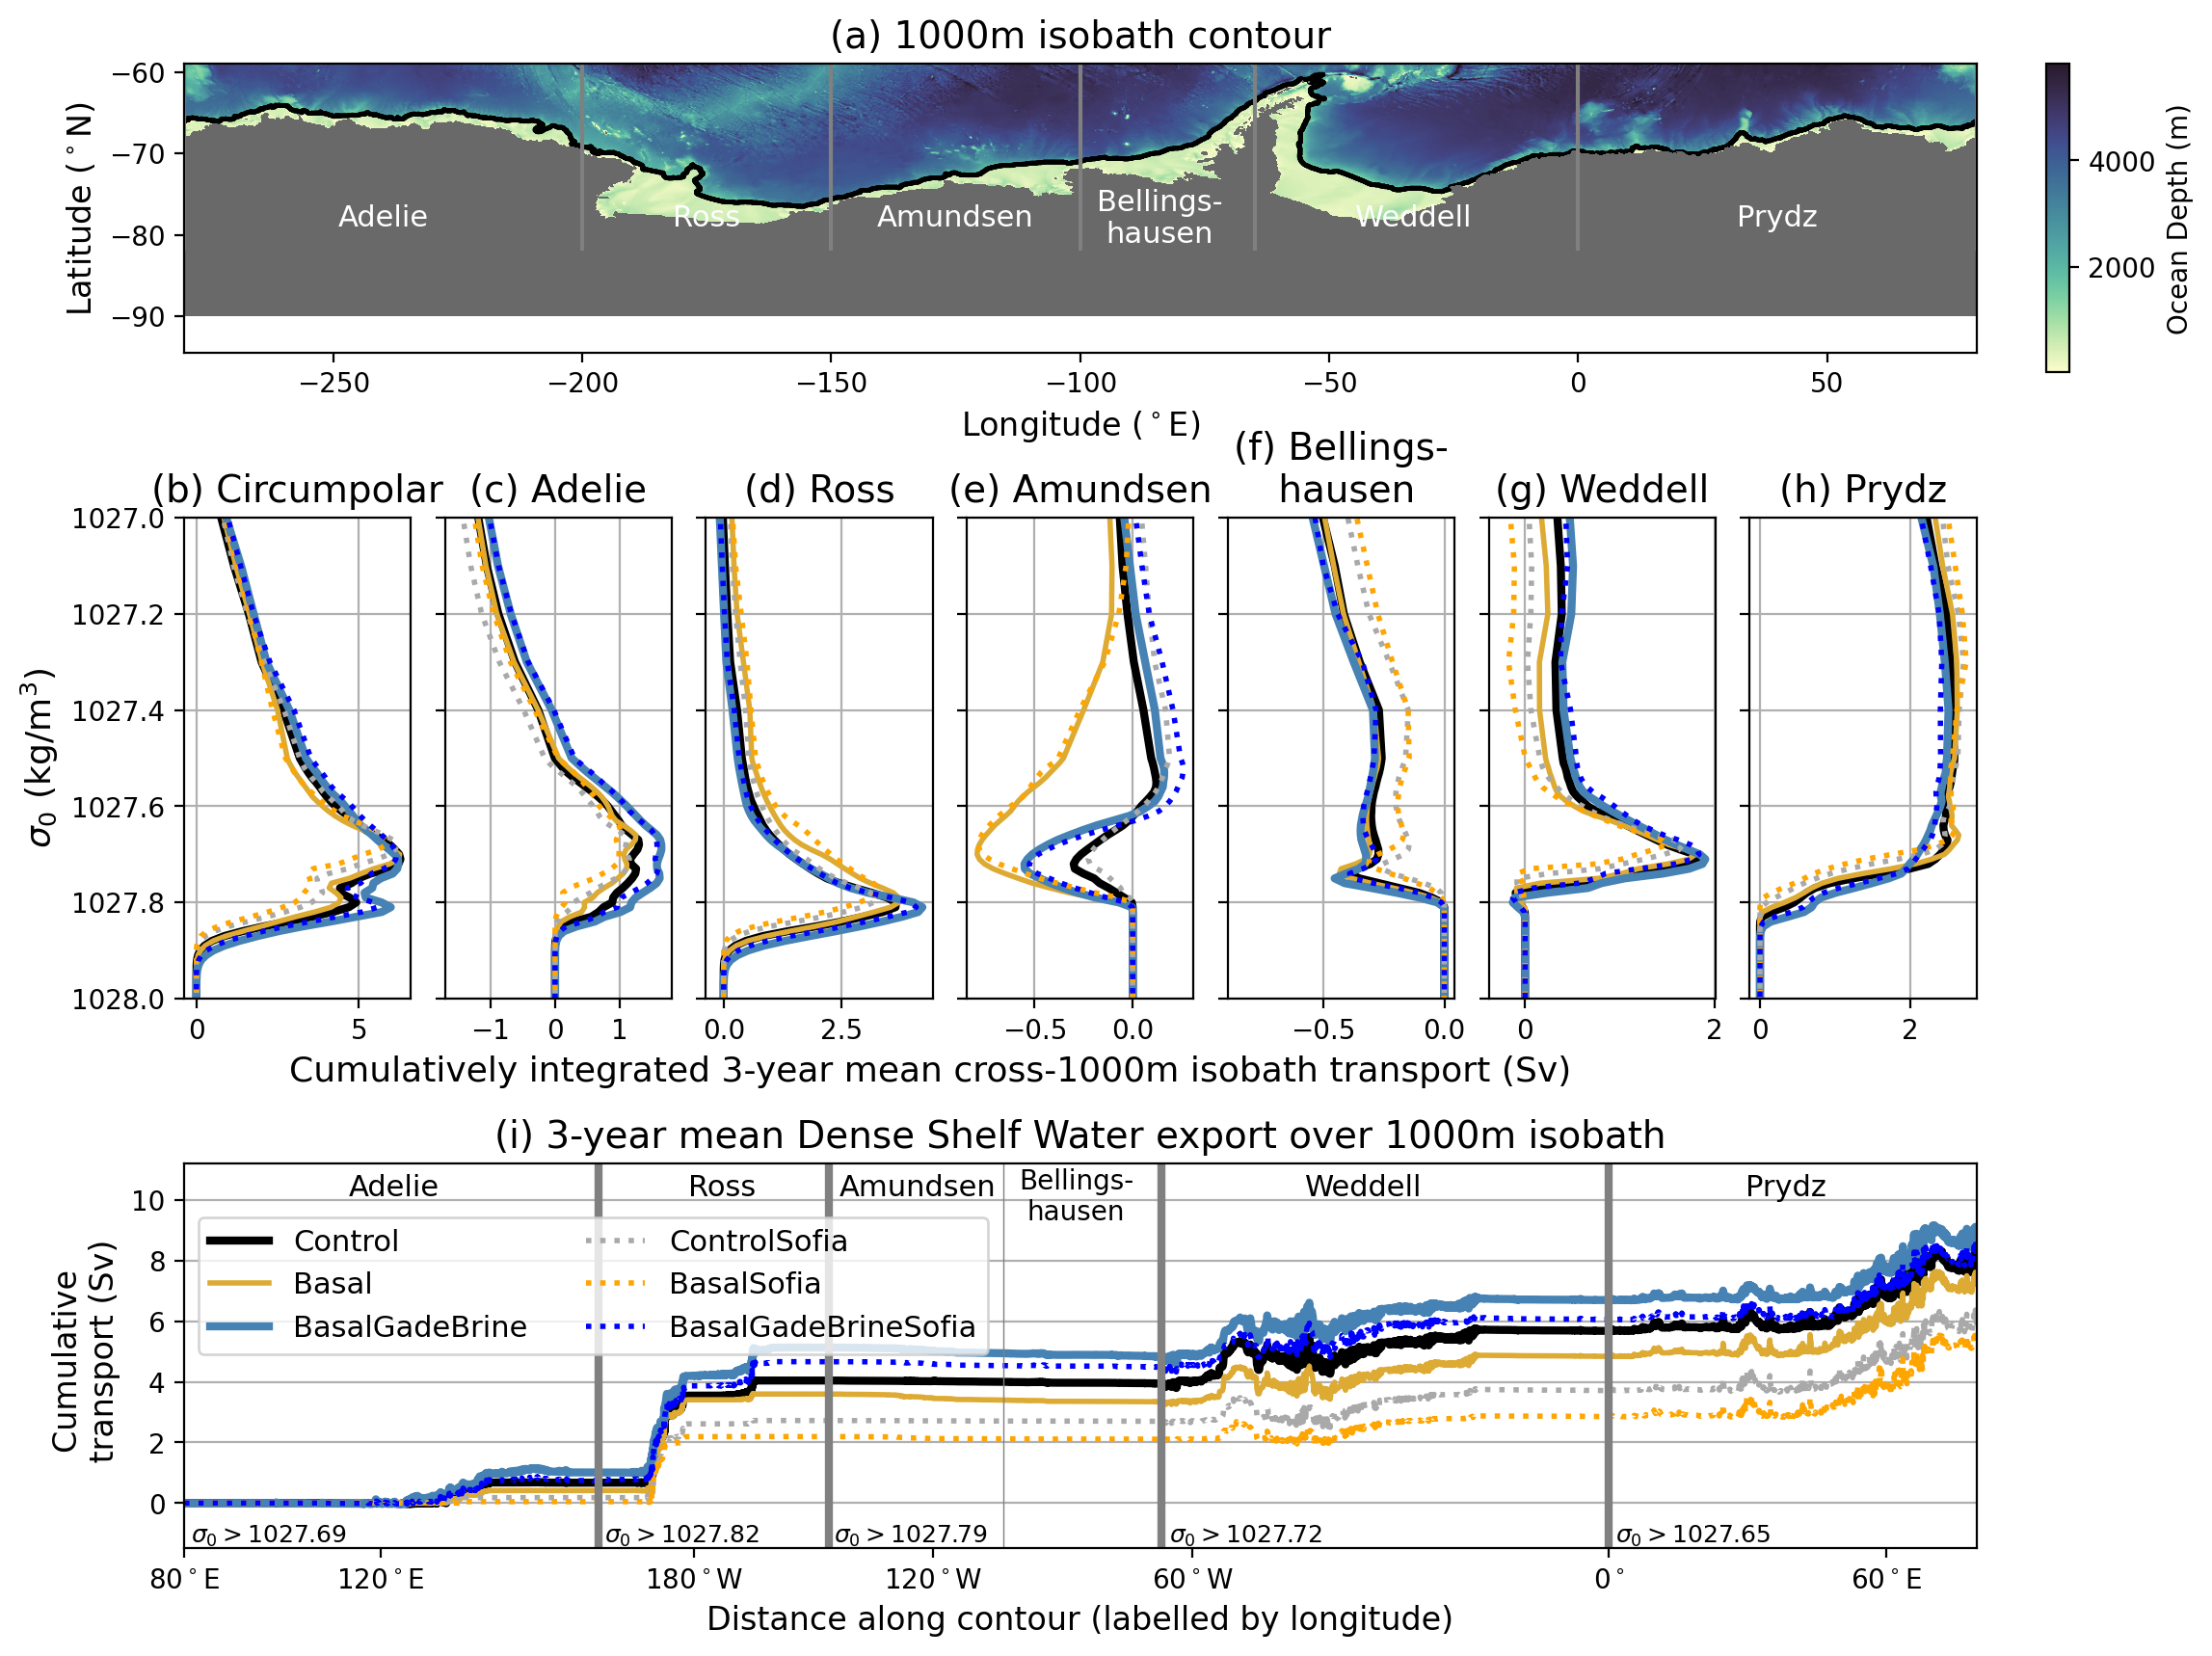

In [45]:
figdir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'

gs = gridspec.GridSpec(3,7, height_ratios = [0.6,1,0.8]) 
fig = plt.figure(figsize = (12,10),dpi = 200)
ax0, ax1, ax2, ax3, ax4, ax4b,ax5,ax6,ax7 = plt.subplot(gs[0,:]), plt.subplot(gs[1,0]), plt.subplot(gs[1,1]), plt.subplot(gs[1,2]),plt.subplot(gs[1,3]),plt.subplot(gs[1,4]),plt.subplot(gs[1,5]),plt.subplot(gs[1,6]),plt.subplot(gs[2,:])

h_plot = ht.plot(ax = ax0, cmap = cm.cm.deep, add_colorbar = False)
cax = plt.axes([0.93,0.72,0.01,0.16])
plt.colorbar(h_plot, cax = cax, label = 'Ocean Depth (m)')
ax0.contour(xt_ocean['xt_ocean'].values, yt_ocean['yt_ocean'].values,np.abs(mask_x_transport.values)+np.abs(mask_y_transport.values),colors = 'k')
ax0.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='dimgrey',zorder=2,)

ax0.vlines([-280,-200,-150,-100,-65,0,80],-82,-58,  color = 'grey')
ax0.text(-240, -78, 'Adelie', horizontalalignment='center',verticalalignment='center',fontsize = 11,color = 'w')
ax0.text(-175, -78, 'Ross', horizontalalignment='center',verticalalignment='center',fontsize = 11,color = 'w')
ax0.text(-125, -78, 'Amundsen', horizontalalignment='center',verticalalignment='center',fontsize = 11,color = 'w')
ax0.text(-84, -78, 'Bellings-\nhausen', horizontalalignment='center',verticalalignment='center',fontsize = 11,color = 'w')
ax0.text(-33, -78, 'Weddell', horizontalalignment='center',verticalalignment='center',fontsize = 11,color = 'w')
ax0.text(40, -78, 'Prydz', horizontalalignment='center',verticalalignment='center',fontsize = 11,color = 'w')

ax0.set_title('(a) 1000m isobath contour', fontsize = 14)
ax0.set_ylabel('Latitude ($^\circ$N)', fontsize = 12)
ax0.set_xlabel('Longitude ($^\circ$E)', fontsize = 12)

save_dir = '/g/data/e14/fbd581/Basal_Pedro_project/updated_git_basal_mom5-collaborative/basal_mom5-collaborative-project/notebooks/cross_contour/'

for n in np.arange(7):
    #print(n)
    ax = [ax1,ax2,ax3,ax4,ax4b,ax5,ax6][n]
    sector = [slice(0,6002),Adelie, Ross, Am,Be, Weddell, Prydz][n]
    sector_name = ['(b) Circumpolar','(c) Adelie', '(d) Ross', '(e) Amundsen','(f) Bellings-\n hausen', '(g) Weddell', '(h) Prydz'][n]
    for i in np.arange(6):
        ekey = keys[i]
        label = exptdict[ekey]['shortname']
        Nice_label = ekey
        # OPEN FROM SAVED ARRAY
        array = xr.open_dataset(save_dir+label+'_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
        color = exptdict[ekey]['colors']
        linestyle = exptdict[ekey]['linestyles']
        linewidth = exptdict[ekey]['linewidth']
        b = (array.isel(variable=0)/1e6).sel(contour_index = sector).sum('contour_index')
        (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(ax = ax, y = 'isopycnal_bins', label = Nice_label,color = color, linestyle = linestyle, linewidth = linewidth)
        print(sector_name, (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).idxmax('isopycnal_bins').values)
    ax.set_ylim(1028.0,1027)
    ax.set_title(sector_name, fontsize = 14)
    ax.grid()
    if n == 0:
        ax.set_ylabel('$\sigma_0$ (kg/m$^3$)', fontsize = 13)
    else:
        ax.set_ylabel('')
        ax.set_yticklabels('')
    if n ==2:
        ax.set_xlabel('                    Cumulatively integrated 3-year mean cross-1000m isobath transport (Sv)', fontsize = 13)  
    else:
        ax.set_xlabel('')


density_sliceAde = slice(1027.69,1030)
density_sliceRos = slice(1027.82,1030)
density_sliceAmBe = slice(1027.79,1030)
density_sliceWe = slice(1027.72,1030)
density_slicePr = slice(1027.65,1030)

for i in np.arange(6):
    ekey = keys[i]
    label = exptdict[ekey]['shortname']
    Nice_label = ekey 
    # OPEN FROM SAVED ARRAY
    array = xr.open_dataset(save_dir+label+'_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
    color = exptdict[ekey]['colors']
    linestyle = exptdict[ekey]['linestyles']
    offset = [0,-0.4,0,0,0,0][i]
    linewidth = exptdict[ekey]['linewidth']
    #copy array so we can fill it with values from the different density bins for different Antarctic sectors
    array_copy = xr.zeros_like(array.isel(isopycnal_bins = 0, variable = 0))
    for j in np.arange(len(array_copy)):
        if j <= 1270: #border of Adelie and Ross
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceAde)).sum('isopycnal_bins').values[j]            
        if j <= 2149: #border between Ross and Amundsen
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceRos)).sum('isopycnal_bins').values[j]
        elif j <= 3338: #border between Bellingshausen and Weddell
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceAmBe)).sum('isopycnal_bins').values[j]
        elif j <=4798: #border between weddell and prydz
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceWe)).sum('isopycnal_bins').values[j]
        else:
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_slicePr)).sum('isopycnal_bins').values[j]
    
    ax7.plot(distance_along_contour,array_copy.cumsum('contour_index'),label = Nice_label, color = color, linestyle = linestyle, linewidth = linewidth)
    # ax7.text(distance_along_contour[-1]+0.2,offset + array_copy.isel(variable=0).cumsum('contour_index')[-1],
    # ax7.text(distance_along_contour[-1]+0.2,array_copy.isel(variable=0).cumsum('contour_index')[-1],
    #          "{:.2f}".format(array_copy.isel(variable=0).cumsum('contour_index')[-1].values) + ' Sv', color = color)
ax7.set_ylabel('Cumulative \n transport (Sv)', fontsize = 12)
ax7.set_xticks(distance_along_contour[distance_indices.astype(int)[:-1]])
ax7.set_xticklabels(('80$^\circ$E','120$^\circ$E','180$^\circ$W','120$^\circ$W','60$^\circ$W','0$^\circ$','60$^\circ$E'));
ax7.set_xlim(0,distance_along_contour[-1]);
ax7.set_xlabel('Distance along contour (labelled by longitude)', fontsize = 12)

inds= [1270, 2149,  3338, 4798]
ax7.vlines(distance_along_contour[inds],-2,11.2,  color = 'grey',linewidth = 3)
inds= [2803]
ax7.vlines(distance_along_contour[inds],-2,11.2,  color = 'grey',linewidth = 0.5)


# region labels
ax7.text(distance_along_contour[635], 10.4, 'Adelie', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[1709], 10.4, 'Ross', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[2500], 10.4, 'Amundsen', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[3050], 10.1, 'Bellings-\nhausen', horizontalalignment='center',verticalalignment='center',fontsize = 10)
ax7.text(distance_along_contour[3900], 10.4, 'Weddell', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[5399], 10.4, 'Prydz', horizontalalignment='center',verticalalignment='center',fontsize = 11)

#density bin labels
ax7.text(distance_along_contour[20], -1.1, '$\sigma_0>1027.69$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[1290], -1.1, '$\sigma_0>1027.82$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[2170], -1.1, '$\sigma_0>1027.79$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[3360], -1.1, '$\sigma_0>1027.72$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[4820], -1.1, '$\sigma_0>1027.65$', horizontalalignment='left',verticalalignment='center',fontsize = 9)


ax7.set_ylim(-1.5,11.2)
ax7.grid(axis = 'y')
ax7.legend(loc = 'upper left',fontsize = 11, ncol=2, bbox_to_anchor = (0,0.9))
ax7.set_title('(i) 3-year mean Dense Shelf Water export over 1000m isobath',fontsize = 14)

fig.subplots_adjust(hspace = 0.43, wspace = 0.15)

plt.savefig(figdir+'Cross-1000m_annual_shelf_yr17-20_ctrlxSOFIA.png',bbox_inches='tight',dpi=300)


a) Circumpolar 1027.7099999999998
a) Circumpolar 1027.6799999999998
a) Circumpolar 1027.5
a) Circumpolar 1027.7199999999998
a) Circumpolar 1027.6999999999998
a) Circumpolar 1027.6399999999999
b) Adelie 1027.6799999999998
b) Adelie 1027.7099999999998
b) Adelie 1027.53
b) Adelie 1027.6899999999998
b) Adelie 1027.7299999999998
b) Adelie 1027.7099999999998
c) Ross 1027.7999999999997
c) Ross 1027.7899999999997
c) Ross 1027.299999999997
c) Ross 1027.8099999999997
c) Ross 1027.8099999999997
c) Ross 1027.8099999999997
d) Amundsen 1027.55
d) Amundsen 1027.5
d) Amundsen 1000.0
d) Amundsen 1027.53
d) Amundsen 1027.52
d) Amundsen 1027.7699999999998
e) Bellings-
 hausen 1027.8199999999997
e) Bellings-
 hausen 1027.8199999999997
e) Bellings-
 hausen 1027.6799999999998
e) Bellings-
 hausen 1027.8299999999997
e) Bellings-
 hausen 1027.8299999999997
e) Bellings-
 hausen 1027.7899999999997
f) Weddell 1027.7099999999998
f) Weddell 1027.6799999999998
f) Weddell 1027.5
f) Weddell 1027.7099999999998
f) Wedd

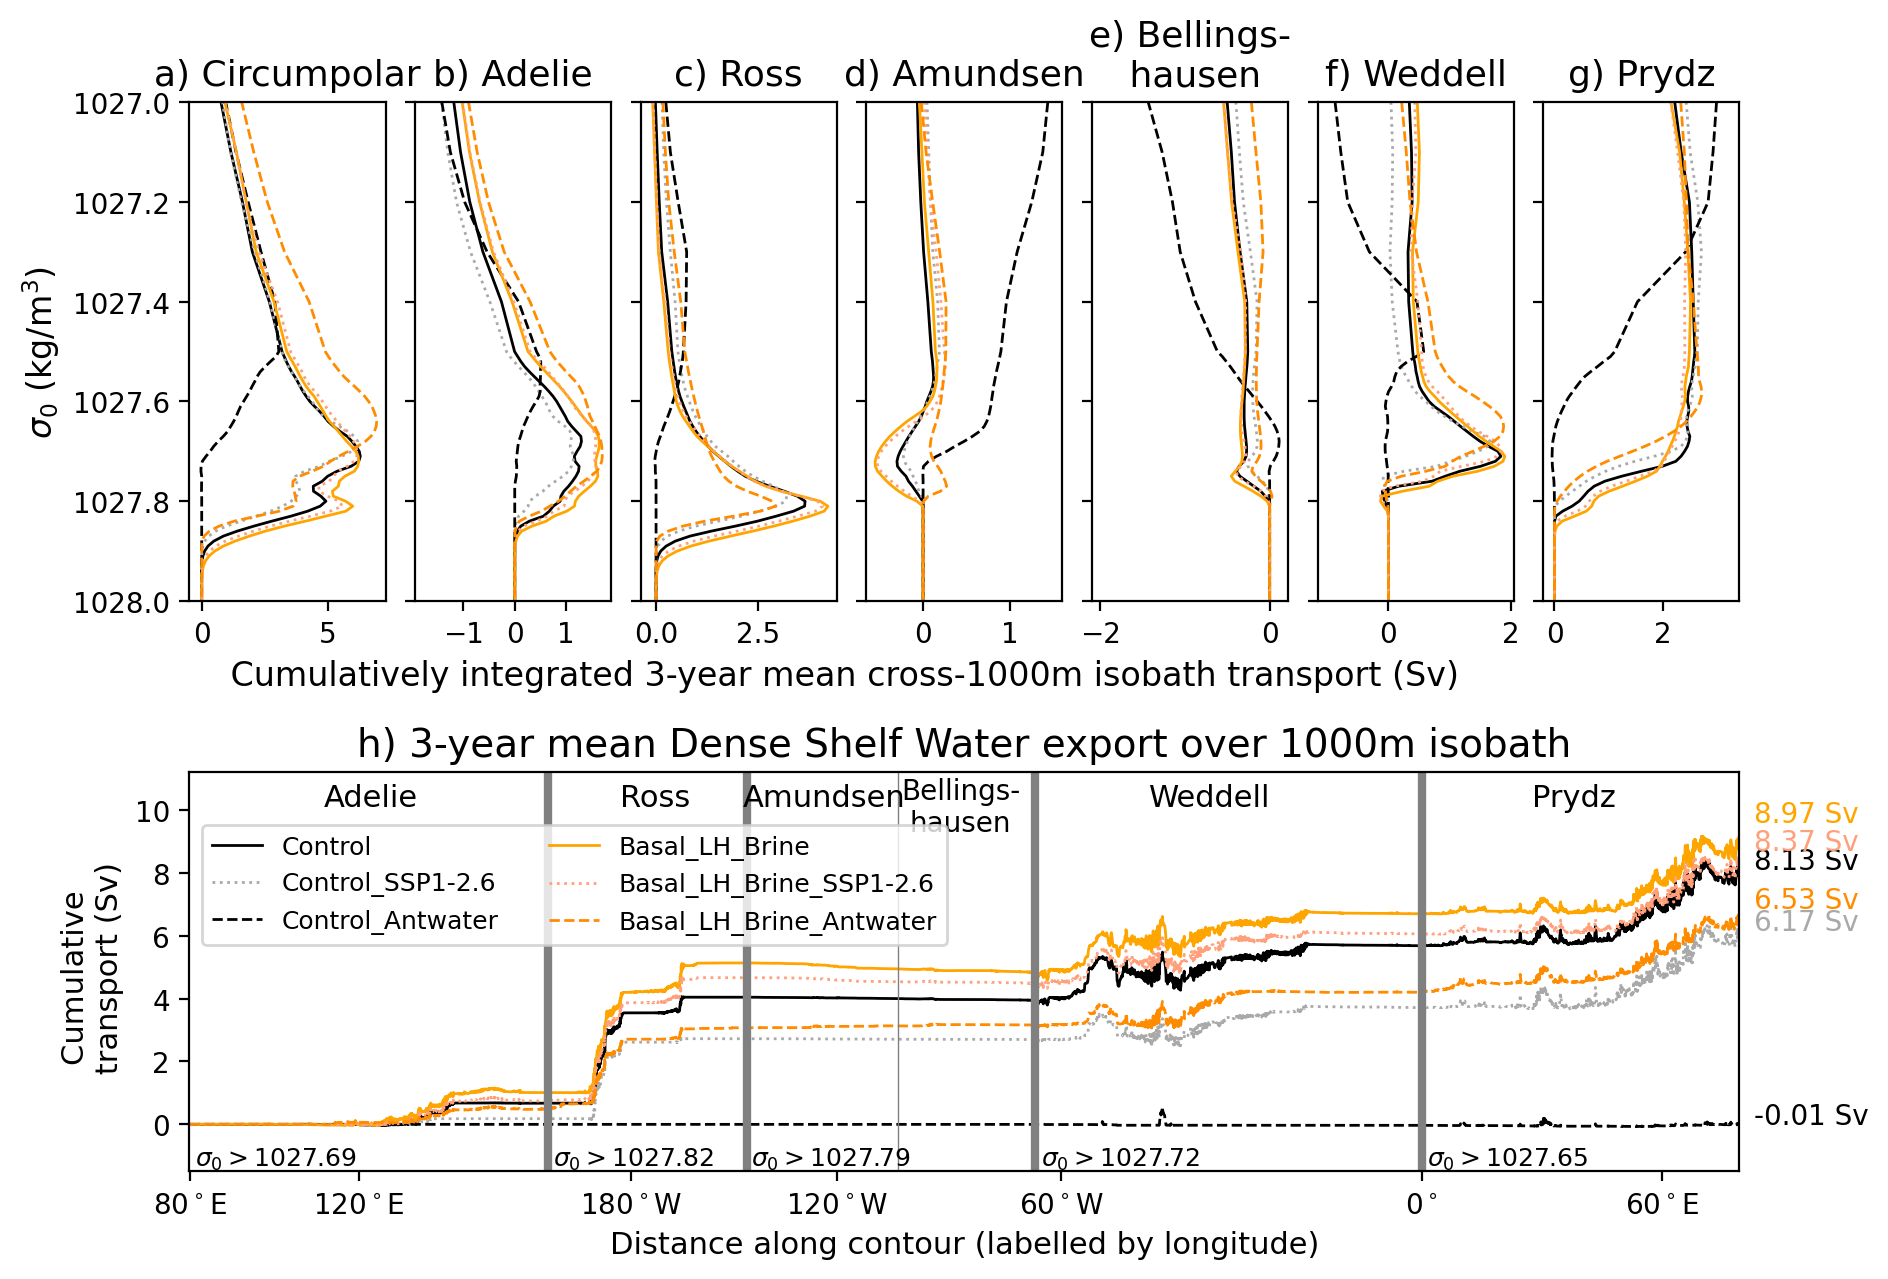

In [46]:
## ONLY CONTROL AND BASAL_LH_BRINE

#dict with plotting colors, linestyles, linewidth, and a shortname which may or may not be useful
exptdict = OrderedDict([
    ('Control',  {'expt':control,
                  'colors':"#000000",'linestyles':'-','linewidth':1,'shortname':'control'}),
    ('Control_SSP1-2.6',  {'expt':control_sofia,
                         'colors':"darkgray",'linestyles':':','linewidth':1,'shortname':'control_sofia'}),
    ('Control_Antwater',  {'expt':control_antwater,
                         'colors':"#000000",'linestyles':'--','linewidth':1,'shortname':'control_antwater'}),
    ('Basal_LH_Brine',  {'expt':basal_gade_brine,
                    'colors':'orange','linestyles':'-','linewidth':1,'shortname':'basal_gade_brine'}),
    ('Basal_LH_Brine_SSP1-2.6',  {'expt':basal_gade_brine_sofia,
                         'colors':"lightsalmon",'linestyles':':','linewidth':1,'shortname':'basal_gade_brine_sofia'}),
    ('Basal_LH_Brine_Antwater',  {'expt':basal_gade_brine_antwater,
                         'colors':"darkorange",'linestyles':'--','linewidth':1,'shortname':'basal_gade_brine_antwater'}),
])
keys = ['Control','Control_SSP1-2.6','Control_Antwater','Basal_LH_Brine','Basal_LH_Brine_SSP1-2.6','Basal_LH_Brine_Antwater']


figdir = '/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'

gs = gridspec.GridSpec(3,7, height_ratios = [0.6,1,0.8]) 
fig = plt.figure(figsize = (10,10),dpi = 200)
# ax0, ax1, ax2, ax3, ax4, ax4b,ax5,ax6,ax7 = plt.subplot(gs[0,:]), plt.subplot(gs[1,0]), plt.subplot(gs[1,1]), plt.subplot(gs[1,2]),plt.subplot(gs[1,3]),plt.subplot(gs[1,4]),plt.subplot(gs[1,5]),plt.subplot(gs[1,6]),plt.subplot(gs[2,:])
ax1, ax2, ax3, ax4, ax4b,ax5,ax6,ax7 = plt.subplot(gs[1,0]), plt.subplot(gs[1,1]), plt.subplot(gs[1,2]),plt.subplot(gs[1,3]),plt.subplot(gs[1,4]),plt.subplot(gs[1,5]),plt.subplot(gs[1,6]),plt.subplot(gs[2,:])

# h_plot = ht.plot(ax = ax0, cmap = cm.cm.deep, add_colorbar = False)
# cax = plt.axes([0.93,0.72,0.01,0.16])
# plt.colorbar(h_plot, cax = cax, label = 'Ocean Depth (m)')
# ax0.contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport.values)+np.abs(mask_y_transport.values),colors = 'k')
# ax0.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='dimgrey',zorder=2,)

# ax0.vlines([-280,-200,-150,-100,-65,0,80],-82,-58,  color = 'grey')
# ax0.text(-240, -78, 'Adelie', horizontalalignment='center',verticalalignment='center',fontsize = 11,color = 'w')
# ax0.text(-175, -78, 'Ross', horizontalalignment='center',verticalalignment='center',fontsize = 11,color = 'w')
# ax0.text(-125, -78, 'Amundsen', horizontalalignment='center',verticalalignment='center',fontsize = 11,color = 'w')
# ax0.text(-84, -78, 'Bellings-\nhausen', horizontalalignment='center',verticalalignment='center',fontsize = 11,color = 'w')
# ax0.text(-33, -78, 'Weddell', horizontalalignment='center',verticalalignment='center',fontsize = 11,color = 'w')
# ax0.text(40, -78, 'Prydz', horizontalalignment='center',verticalalignment='center',fontsize = 11,color = 'w')

# ax0.set_title('(a) 1000m isobath contour', fontsize = 14)
# ax0.set_ylabel('Latitude ($^\circ$N)', fontsize = 12)
# ax0.set_xlabel('Longitude ($^\circ$E)', fontsize = 12)

for n in np.arange(7):
    #print(n)
    ax = [ax1,ax2,ax3,ax4,ax4b,ax5,ax6][n]
    sector = [slice(0,6002),Adelie, Ross, Am,Be, Weddell, Prydz][n]
    sector_name = ['a) Circumpolar','b) Adelie', 'c) Ross', 'd) Amundsen','e) Bellings-\n hausen', 'f) Weddell', 'g) Prydz'][n]
    for i in np.arange(6):
        ekey = keys[i]
        label = exptdict[ekey]['shortname']
        Nice_label = ekey
        # OPEN FROM SAVED ARRAY
        array = xr.open_dataset(save_dir+label+'_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
        color = exptdict[ekey]['colors']
        linestyle = exptdict[ekey]['linestyles']
        linewidth = exptdict[ekey]['linewidth']
        b = (array.isel(variable=0)/1e6).sel(contour_index = sector).sum('contour_index')
        (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(ax = ax, y = 'isopycnal_bins', label = Nice_label,color = color, linestyle = linestyle, linewidth = linewidth)
        print(sector_name, (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).idxmax('isopycnal_bins').values)
    ax.set_ylim(1028.0,1027)
    ax.set_title(sector_name, fontsize = 13)
    # ax.grid()
    if n == 0:
        ax.set_ylabel('$\sigma_0$ (kg/m$^3$)', fontsize = 12)
    else:
        ax.set_ylabel('')
        ax.set_yticklabels('')
    if n ==2:
        ax.set_xlabel('                    Cumulatively integrated 3-year mean cross-1000m isobath transport (Sv)', fontsize = 12)  
    else:
        ax.set_xlabel('')


density_sliceAde = slice(1027.69,1030)
density_sliceRos = slice(1027.82,1030)
density_sliceAmBe = slice(1027.79,1030)
density_sliceWe = slice(1027.72,1030)
density_slicePr = slice(1027.65,1030)

for i in np.arange(6):
    ekey = keys[i]
    label = exptdict[ekey]['shortname']
    Nice_label = ekey 
    # OPEN FROM SAVED ARRAY
    array = xr.open_dataset(save_dir+label+'_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
    color = exptdict[ekey]['colors']
    linestyle = exptdict[ekey]['linestyles']
    offset = [0,0,0,0.65,0.35,0.35][i]
    linewidth = exptdict[ekey]['linewidth']
    #copy array so we can fill it with values from the different density bins for different Antarctic sectors
    array_copy = xr.zeros_like(array.isel(isopycnal_bins = 0, variable = 0))
    for j in np.arange(len(array_copy)):
        if j <= 1270: #border of Adelie and Ross
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceAde)).sum('isopycnal_bins').values[j]            
        if j <= 2149: #border between Ross and Amundsen
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceRos)).sum('isopycnal_bins').values[j]
        elif j <= 3338: #border between Bellingshausen and Weddell
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceAmBe)).sum('isopycnal_bins').values[j]
        elif j <=4798: #border between weddell and prydz
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceWe)).sum('isopycnal_bins').values[j]
        else:
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_slicePr)).sum('isopycnal_bins').values[j]
    
    ax7.plot(distance_along_contour,array_copy.cumsum('contour_index'),label = Nice_label, color = color, linestyle = linestyle, linewidth = linewidth)

    print('DEBUG!')
    print(array_copy)

    
    # ax7.text(distance_along_contour[-1]+0.2,offset + array_copy.isel(variable=0).cumsum('contour_index')[-1],
    #          "{:.2f}".format(array_copy.isel(variable=0).cumsum('contour_index')[-1].values) + ' Sv', color = color)
    ax7.text(distance_along_contour[-1]+0.2,offset + array_copy.cumsum('contour_index')[-1],
             "{:.2f}".format(array_copy.cumsum('contour_index')[-1].values) + ' Sv', color = color)
ax7.set_ylabel('Cumulative \n transport (Sv)', fontsize = 11)
ax7.set_xticks(distance_along_contour[distance_indices.astype(int)[:-1]])
ax7.set_xticklabels(('80$^\circ$E','120$^\circ$E','180$^\circ$W','120$^\circ$W','60$^\circ$W','0$^\circ$','60$^\circ$E'));
ax7.set_xlim(0,distance_along_contour[-1]);
ax7.set_xlabel('Distance along contour (labelled by longitude)', fontsize = 11)

inds= [1270, 2149,  3338, 4798]
ax7.vlines(distance_along_contour[inds],-2,11.2,  color = 'grey',linewidth = 3)
inds= [2803]
ax7.vlines(distance_along_contour[inds],-2,11.2,  color = 'grey',linewidth = 0.5)


# region labels
ax7.text(distance_along_contour[635], 10.4, 'Adelie', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[1709], 10.4, 'Ross', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[2500], 10.4, 'Amundsen', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[3050], 10.1, 'Bellings-\nhausen', horizontalalignment='center',verticalalignment='center',fontsize = 10)
ax7.text(distance_along_contour[3900], 10.4, 'Weddell', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[5399], 10.4, 'Prydz', horizontalalignment='center',verticalalignment='center',fontsize = 11)

#density bin labels
ax7.text(distance_along_contour[20], -1.1, '$\sigma_0>1027.69$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[1290], -1.1, '$\sigma_0>1027.82$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[2170], -1.1, '$\sigma_0>1027.79$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[3360], -1.1, '$\sigma_0>1027.72$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[4820], -1.1, '$\sigma_0>1027.65$', horizontalalignment='left',verticalalignment='center',fontsize = 9)


ax7.set_ylim(-1.5,11.2)
# ax7.grid(axis = 'y')
ax7.legend(loc = 'upper left',fontsize = 9, ncol=2, bbox_to_anchor = (0,0.9))
ax7.set_title('h) 3-year mean Dense Shelf Water export over 1000m isobath',fontsize = 14)

fig.subplots_adjust(hspace = 0.43, wspace = 0.15)

plt.savefig(figdir+'Cross-1000m_annual_shelf_yr17-20_ctrlxSOFIA_v2.png',bbox_inches='tight',dpi=300)


In [47]:
print(figdir+'Cross-1000m_annual_shelf_yr17-20_ctrlxSOFIA_v2.png')

/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/Cross-1000m_annual_shelf_yr17-20_ctrlxSOFIA_v2.png


In [48]:
ls /g/data/e14/fbd581/Basal_Pedro_project/updated_git_basal_mom5-collaborative/basal_mom5-collaborative-project/notebooks/cross_contour/

PBS-script-code/
basal_gade_brine_antwater_vol_trans_across_contour_binned_last_3yr.nc
basal_gade_brine_sofia_vol_trans_across_contour_binned_last_3yr.nc
basal_gade_brine_ssp126_vol_trans_across_contour_binned_last_3yr.nc
basal_gade_brine_vol_trans_across_contour_binned_last_3yr.nc
basal_nogade_sofia_vol_trans_across_contour_binned_last_3yr.nc
basal_nogade_ssp126_vol_trans_across_contour_binned_last_3yr.nc
basal_nogade_vol_trans_across_contour_binned_last_3yr.nc
control_antwater_gade_vol_trans_across_contour_binned_last_3yr.nc
control_antwater_vol_trans_across_contour_binned_last_3yr.nc
control_gade_antwater_vol_trans_across_contour_binned_last_3yr.nc
control_gade_vol_trans_across_contour_binned_last_3yr.nc
control_sofia_vol_trans_across_contour_binned_last_3yr.nc
control_ssp126_vol_trans_across_contour_binned_last_3yr.nc
control_vol_trans_across_contour_binned_last_3yr.nc
old/
plot_volume_transports-combined-plot.ipynb
plot_volume_transports-combined-plot_SOFIA.ipynb


In [49]:
array1 = xr.open_dataset(save_dir+'control_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
array2 = xr.open_dataset(save_dir+'control_antwater_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
array3 = xr.open_dataset(save_dir+'control_gade_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
array4 = xr.open_dataset(save_dir+'control_gade_antwater_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
array5 = xr.open_dataset(save_dir+'control_antwater_gade_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
array6 = xr.open_dataset(save_dir+'basal_gade_brine_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
array7 = xr.open_dataset(save_dir+'basal_gade_brine_antwater_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr


In [50]:
figdir


'/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/'

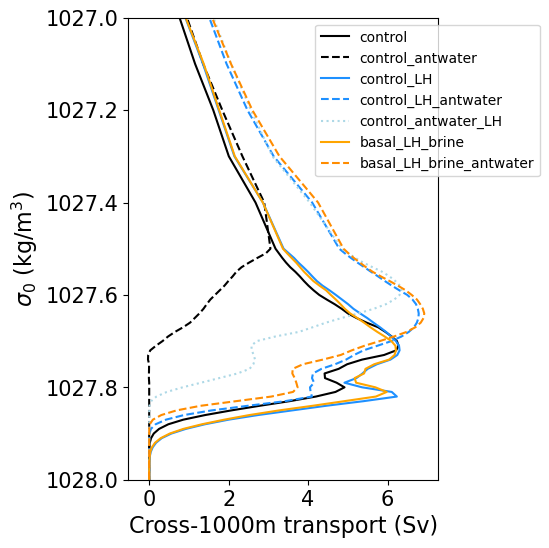

In [51]:

fig = plt.figure(figsize = (4,6))

# OPEN FROM SAVED ARRAY
b = (array1.isel(variable=0)/1e6).sel(contour_index = slice(0,6002)).sum('contour_index')
(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(y = 'isopycnal_bins',label='control',color='#000000')

b = (array2.isel(variable=0)/1e6).sel(contour_index = slice(0,6002)).sum('contour_index')
(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(y = 'isopycnal_bins',linestyle='--',label='control_antwater',color='#000000')

b = (array3.isel(variable=0)/1e6).sel(contour_index = slice(0,6002)).sum('contour_index')
(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(y = 'isopycnal_bins',linestyle='-',label='control_LH',color='dodgerblue')

b = (array4.isel(variable=0)/1e6).sel(contour_index = slice(0,6002)).sum('contour_index')
(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(y = 'isopycnal_bins',linestyle='--',label='control_LH_antwater',color='dodgerblue')

b = (array5.isel(variable=0)/1e6).sel(contour_index = slice(0,6002)).sum('contour_index')
(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(y = 'isopycnal_bins',linestyle=':',label='control_antwater_LH',color='lightblue')

b = (array6.isel(variable=0)/1e6).sel(contour_index = slice(0,6002)).sum('contour_index')
(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(y = 'isopycnal_bins',linestyle='-',label='basal_LH_brine',color='orange')

b = (array7.isel(variable=0)/1e6).sel(contour_index = slice(0,6002)).sum('contour_index')  
(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(y = 'isopycnal_bins',linestyle='--',label='basal_LH_brine_antwater',color='darkorange')

plt.legend(loc = 'upper right', bbox_to_anchor = (+1.35,1))
plt.ylim(1028.0,1027)
plt.ylabel('$\sigma_0$ (kg/m$^3$)', fontsize = 16)
plt.xlabel('Cross-1000m transport (Sv)', fontsize = 16)
plt.title('', fontsize = 16)

plt.tick_params(axis='x', labelsize=15)  # Set x-tick font size
plt.tick_params(axis='y', labelsize=15)  # Set y-tick font size

plt.savefig(figdir+'Cross-1000m_annual_shelf_yr17-20_ctrl_LH.png',bbox_inches='tight',dpi=300)
plt.show()


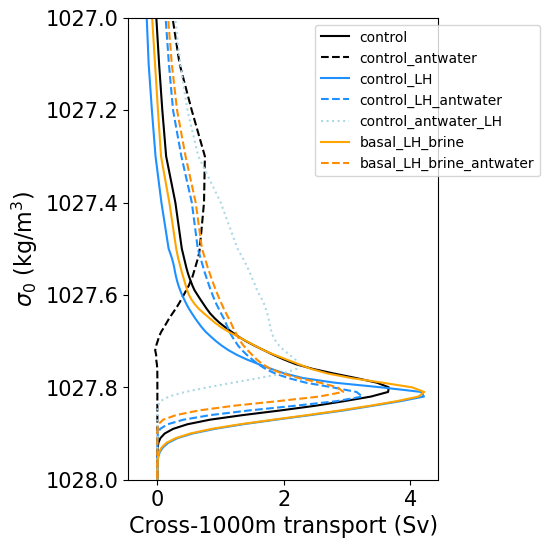

In [52]:

fig = plt.figure(figsize = (4,6))

# OPEN FROM SAVED ARRAY
b = (array1.isel(variable=0)/1e6).sel(contour_index = Ross).sum('contour_index')
(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(y = 'isopycnal_bins',label='control',color='#000000')

b = (array2.isel(variable=0)/1e6).sel(contour_index = Ross).sum('contour_index')
(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(y = 'isopycnal_bins',linestyle='--',label='control_antwater',color='#000000')

b = (array3.isel(variable=0)/1e6).sel(contour_index = Ross).sum('contour_index')
(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(y = 'isopycnal_bins',linestyle='-',label='control_LH',color='dodgerblue')

b = (array4.isel(variable=0)/1e6).sel(contour_index = Ross).sum('contour_index')
(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(y = 'isopycnal_bins',linestyle='--',label='control_LH_antwater',color='dodgerblue')

b = (array5.isel(variable=0)/1e6).sel(contour_index = Ross).sum('contour_index')
(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(y = 'isopycnal_bins',linestyle=':',label='control_antwater_LH',color='lightblue')

b = (array6.isel(variable=0)/1e6).sel(contour_index = Ross).sum('contour_index')
(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(y = 'isopycnal_bins',linestyle='-',label='basal_LH_brine',color='orange')

b = (array7.isel(variable=0)/1e6).sel(contour_index = Ross).sum('contour_index')  
(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(y = 'isopycnal_bins',linestyle='--',label='basal_LH_brine_antwater',color='darkorange')

plt.legend(loc = 'upper right', bbox_to_anchor = (+1.35,1))
plt.ylim(1028.0,1027)
plt.ylabel('$\sigma_0$ (kg/m$^3$)', fontsize = 16)
plt.xlabel('Cross-1000m transport (Sv)', fontsize = 16)
plt.title('', fontsize = 16)

plt.tick_params(axis='x', labelsize=15)  # Set x-tick font size
plt.tick_params(axis='y', labelsize=15)  # Set y-tick font size

plt.savefig(figdir+'Cross-1000m_annual_shelf_yr17-20_ctrl_LH_Ross.png',bbox_inches='tight',dpi=300)
plt.show()


In [ ]:
# New GRL Fig. 2 paper (also only CONTROL & BASAL_LH_BRINE)

fig = plt.figure(figsize=(12, 10), dpi=200)

# Main 1x2 frame
gs_main = gridspec.GridSpec(1, 2, width_ratios=[3, 4], wspace=0.25)

# LEFT: 3x3 area (one big axes across it)
gs_left = gridspec.GridSpecFromSubplotSpec(3, 3, subplot_spec=gs_main[0])
ax_map = plt.subplot(gs_left[:, :])

# RIGHT: two stacked plots
gs_right = gridspec.GridSpecFromSubplotSpec(1, 1, subplot_spec=gs_main[1], hspace=0.25)
ax7 = plt.subplot(gs_right[0])


for i in np.arange(6):
    ekey = keys[i]
    label = exptdict[ekey]['shortname']
    Nice_label = ekey 
    # OPEN FROM SAVED ARRAY
    array = xr.open_dataset(save_dir+label+'_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
    color = exptdict[ekey]['colors']
    linestyle = exptdict[ekey]['linestyles']
    offset = [0,-0.4,0,0,0,0][i]
    linewidth = exptdict[ekey]['linewidth']
    #copy array so we can fill it with values from the different density bins for different Antarctic sectors
    array_copy = xr.zeros_like(array.isel(isopycnal_bins = 0, variable = 0))
    for j in np.arange(len(array_copy)):
        if j <= 1270: #border of Adelie and Ross
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceAde)).sum('isopycnal_bins').values[j]            
        if j <= 2149: #border between Ross and Amundsen
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceRos)).sum('isopycnal_bins').values[j]
        elif j <= 3338: #border between Bellingshausen and Weddell
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceAmBe)).sum('isopycnal_bins').values[j]
        elif j <=4798: #border between weddell and prydz
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceWe)).sum('isopycnal_bins').values[j]
        else:
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_slicePr)).sum('isopycnal_bins').values[j]
    
    ax7.plot(distance_along_contour,array_copy.cumsum('contour_index'),label = Nice_label, color = color, linestyle = linestyle, linewidth = linewidth)
    ax7.text(distance_along_contour[-1]+0.25,array_copy.cumsum('contour_index')[-1],
             "{:.2f}".format(array_copy.cumsum('contour_index')[-1].values) + ' Sv', color = color)
ax7.set_ylabel('Cumulative \n transport (Sv)', fontsize = 11)
ax7.set_xticks(distance_along_contour[distance_indices.astype(int)[:-1]])
ax7.set_xticklabels(('80$^\circ$E','120$^\circ$E','180$^\circ$W','120$^\circ$W','60$^\circ$W','0$^\circ$','60$^\circ$E'));
ax7.set_xlim(0,distance_along_contour[-1]);
ax7.set_xlabel('Distance along contour (labelled by longitude)', fontsize = 11)

inds= [1270, 2149,  3338, 4798]
ax7.vlines(distance_along_contour[inds],-2,11.2,  color = 'grey',linewidth = 3)
inds= [2803]
ax7.vlines(distance_along_contour[inds],-2,11.2,  color = 'grey',linewidth = 0.5)


# region labels
ax7.text(distance_along_contour[635], 10.4, 'Adelie', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[1709], 10.4, 'Ross', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[2500], 10.4, 'Amundsen', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[3050], 10.1, 'Bellings-\nhausen', horizontalalignment='center',verticalalignment='center',fontsize = 10)
ax7.text(distance_along_contour[3900], 10.4, 'Weddell', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[5399], 10.4, 'Prydz', horizontalalignment='center',verticalalignment='center',fontsize = 11)

#density bin labels
ax7.text(distance_along_contour[20], -1.1, '$\sigma_0>1027.69$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[1290], -1.1, '$\sigma_0>1027.82$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[2170], -1.1, '$\sigma_0>1027.79$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[3360], -1.1, '$\sigma_0>1027.72$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[4820], -1.1, '$\sigma_0>1027.65$', horizontalalignment='left',verticalalignment='center',fontsize = 9)


ax7.set_ylim(-1.5,11.2)
# ax7.grid(axis = 'y')
ax7.legend(loc = 'upper left',fontsize = 9, ncol=2, bbox_to_anchor = (0,0.9))
ax7.set_title('h) 3-year mean Dense Shelf Water export over 1000m isobath',fontsize = 14)

### MOC plot:
# ax_right_bottom = plt.subplot(gs_right[1])



plt.savefig(figdir+'Cross-1000m_annual_shelf_yr17-20_ctrlxSOFIA_Fig2.png',bbox_inches='tight',dpi=300)


In [51]:
print(figdir+'Cross-1000m_annual_shelf_yr17-20_ctrlxSOFIA_Fig2.png')

/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/Cross-1000m_annual_shelf_yr17-20_ctrlxSOFIA_Fig2.png


#### Attempt of timeseries of circumpolar DSW export:

In [52]:
array=control_vol_trans_ctrl.vol_trans_across_contour_binned
array

<xarray.DataArray 'vol_trans_across_contour_binned' (time: 240,
                                                     isopycnal_bins: 128,
                                                     contour_index: 6002)> Size: 1GB
dask.array<setitem, shape=(240, 128, 6002), dtype=float64, chunksize=(240, 128, 6002), chunktype=numpy.ndarray>
Coordinates:
  * time            (time) object 2kB 1900-01-16 12:00:00 ... 1919-12-16 12:0...
  * isopycnal_bins  (isopycnal_bins) float64 1kB 1e+03 1.024e+03 ... 1.04e+03
  * contour_index   (contour_index) int64 48kB 1 2 3 4 5 ... 5999 6000 6001 6002

In [53]:
array_copy = xr.zeros_like(array.isel(isopycnal_bins = 0))
array_copy.shape

(240, 6002)

In [58]:
(10**(-6)*array.sel(isopycnal_bins = density_sliceAde)).sum('isopycnal_bins').values[:,1270].shape

(240,)

In [63]:
def rho_integ_monthly (in_array):

    array=control_vol_trans_ctrl.vol_trans_across_contour_binned

    array_copy = xr.zeros_like(array.isel(isopycnal_bins = 0))

    for j in np.arange(len(array_copy)):
        if j <= 1270: #border of Adelie and Ross
            # tmp = (10**(-6)*array.sel(isopycnal_bins = density_sliceAde)).sum('isopycnal_bins').values[:,j] 
            # print(tmp.shape)
            # array_copy[:,j] = tmp
            array_copy[:,j] = (10**(-6)*array.sel(isopycnal_bins = density_sliceAde)).sum('isopycnal_bins').values[:,j] 
        if j <= 2149: #border between Ross and Amundsen
            array_copy[:,j] = (10**(-6)*array.sel(isopycnal_bins = density_sliceRos)).sum('isopycnal_bins').values[:,j]
        elif j <= 3338: #border between Bellingshausen and Weddell
            array_copy[:,j] = (10**(-6)*array.sel(isopycnal_bins = density_sliceAmBe)).sum('isopycnal_bins').values[:,j]
        elif j <=4798: #border between weddell and prydz
            array_copy[:,j] = (10**(-6)*array.sel(isopycnal_bins = density_sliceWe)).sum('isopycnal_bins').values[:,j]
        else:
            array_copy[:,j] = (10**(-6)*array.sel(isopycnal_bins = density_slicePr)).sum('isopycnal_bins').values[:,j]

    return array_copy

In [ ]:
%%time
control_vol_trans_ctrl_mon = rho_integ_monthly(control_vol_trans_ctrl.vol_trans_across_contour_binned)


In [ ]:
%%time
control_vol_trans_ctrl_s_mon = rho_integ_monthly(control_vol_trans_ctrl_s.vol_trans_across_contour_binned)
control_vol_trans_ctrl_a_mon = rho_integ_monthly(control_vol_trans_ctrl_a.vol_trans_across_contour_binned)
control_vol_trans_ctrlBG_mon = rho_integ_monthly(control_vol_trans_ctrlBG.vol_trans_across_contour_binned)
control_vol_trans_ctrlBG_a_mon = rho_integ_monthly(control_vol_trans_ctrlBG_a.vol_trans_across_contour_binned)
control_vol_trans_ctrl_a_BG_mon = rho_integ_monthly(control_vol_trans_ctrl_a_BG.vol_trans_across_contour_binned)


In [ ]:
%%time
control_vol_trans_noBG_mon = rho_integ_monthly(control_vol_trans_noBG.vol_trans_across_contour_binned)
control_vol_trans_noBG_s_mon = rho_integ_monthly(control_vol_trans_noBG_s.vol_trans_across_contour_binned)


In [ ]:
%%time
control_vol_trans_noBG_mon = rho_integ_monthly(control_vol_trans_noBG.vol_trans_across_contour_binned)
control_vol_trans_noBG_s_mon = rho_integ_monthly(control_vol_trans_noBG_s.vol_trans_across_contour_binned)


In [ ]:
for i in np.arange(6):
    # ekey = keys[i]
    # label = exptdict[ekey]['shortname']
    # Nice_label = ekey 
    # # OPEN FROM SAVED ARRAY
    
array = xr.open_dataset(save_dir+label+'_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
color = exptdict[ekey]['colors']
linestyle = exptdict[ekey]['linestyles']
offset = [0,-0.4,0,0,0,0][i]
linewidth = exptdict[ekey]['linewidth']
#copy array so we can fill it with values from the different density bins for different Antarctic sectors
array_copy = xr.zeros_like(array.isel(isopycnal_bins = 0, variable = 0))
for j in np.arange(len(array_copy)):
    if j <= 1270: #border of Adelie and Ross
        array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceAde)).sum('isopycnal_bins').values[j]            
    if j <= 2149: #border between Ross and Amundsen
        array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceRos)).sum('isopycnal_bins').values[j]
    elif j <= 3338: #border between Bellingshausen and Weddell
        array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceAmBe)).sum('isopycnal_bins').values[j]
    elif j <=4798: #border between weddell and prydz
        array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceWe)).sum('isopycnal_bins').values[j]
    else:
        array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_slicePr)).sum('isopycnal_bins').values[j]
    

#### Print values of cross-1000m transport:

In [106]:
## print last values of cross-1000m transport per experiment:

DSWexp_values = np.empty((6,6))

for i in np.arange(6):
    ekey = keys[i]
    label = exptdict[ekey]['shortname']
    Nice_label = ekey 
    # OPEN FROM SAVED ARRAY
    array = xr.open_dataset(save_dir+label+'_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr

    #copy array so we can fill it with values from the different density bins for different Antarctic sectors
    array_copy = xr.zeros_like(array.isel(isopycnal_bins = 0, variable = 0))
    for j in np.arange(len(array_copy)):
        if j <= 1270: #border of Adelie and Ross
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceAde)).sum('isopycnal_bins').values[j]            
        if j <= 2149: #border between Ross and Amundsen
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceRos)).sum('isopycnal_bins').values[j]
        elif j <= 3338: #border between Bellingshausen and Weddell
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceAmBe)).sum('isopycnal_bins').values[j]
        elif j <=4798: #border between weddell and prydz
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_sliceWe)).sum('isopycnal_bins').values[j]
        else:
            array_copy[j] = (10**(-6)*array.isel(variable=0).sel(isopycnal_bins = density_slicePr)).sum('isopycnal_bins').values[j]

    adelie_transp = array_copy.cumsum('contour_index')[1270].values
    ross_transp = array_copy.cumsum('contour_index')[2149].values - array_copy.cumsum('contour_index')[1270].values
    want_transp = array_copy.cumsum('contour_index')[3338].values - array_copy.cumsum('contour_index')[2149].values
    wedd_transp = array_copy.cumsum('contour_index')[4798].values - array_copy.cumsum('contour_index')[3338].values
    pryd_tranp = array_copy.cumsum('contour_index')[-1].values - array_copy.cumsum('contour_index')[4798].values
    circum_transp = array_copy.cumsum('contour_index')[-1].values
    
    print(' === ',Nice_label,' === ')
    print('Adelie',adelie_transp)
    print('Ross',ross_transp)
    print('Amund/Bells',want_transp)
    print('Weddell',wedd_transp)
    print('Prydz',pryd_tranp)
    print('circumpolar',array_copy.cumsum('contour_index')[-1].values)
    print(' =========================== ')

    # assign values to DSWexp_values:
    DSWexp_values[i,:] = [adelie_transp,ross_transp,want_transp,wedd_transp,pryd_tranp,circum_transp ]

 ===  Control  === 
Adelie 0.4464317594608098
Ross 2.253743449916857
Amund/Bells -0.054594962103943434
Weddell 1.1700762982122415
Prydz 1.6100839606770028
circumpolar 5.425740506162968
 ===  Control_SSP1-2.6  === 
Adelie 0.17977048570905543
Ross 2.5462329203001293
Amund/Bells -0.029158955922857555
Weddell 1.0205001527785287
Prydz 2.4481823568292493
circumpolar 6.165526959694105
 ===  Control_Antwater  === 
Adelie 0.0
Ross 0.0
Amund/Bells 0.0
Weddell -0.03181129211423453
Prydz 0.025425790211857695
circumpolar -0.0063855019023768365
 ===  Basal_LH_Brine  === 
Adelie 1.0108017004845933
Ross 4.126138574240352
Amund/Bells -0.29403593865458255
Weddell 1.860397979802169
Prydz 2.2629393483552978
circumpolar 8.96624166422783
 ===  Basal_LH_Brine_SSP1-2.6  === 
Adelie 0.758582683944066
Ross 3.9122374260743977
Amund/Bells -0.17855224835333594
Weddell 1.5716104689698946
Prydz 2.3049344595172627
circumpolar 8.368812790152285
 ===  Basal_LH_Brine_Antwater  === 
Adelie 0.5175897242906954
Ross 2.55583

In [107]:
print('Reduction at SSP126 scenario:')
print('control', 100-(6.165526959694105*100)/8.128622799914126)
print('basal',100-(5.44410483370174*100)/7.4425884139470755)
print('basal_LH_brine',100 - (8.368812790152285*100)/8.96624166422783)

Reduction at SSP126 scenario:
control 24.150411312489
basal 26.851996497619936
basal_LH_brine 6.663091364791981


In [108]:
print('Reduction at Antwater scenario:')
print('control', 100-(0.0063855019023768365*100)/8.128622799914126)
print('basal_LH_brine',100 - (6.531437701757018*100)/8.96624166422783)

Reduction at Antwater scenario:
control 99.92144423404116
basal_LH_brine 27.15523464178787


In [109]:
DSWexp_values

array([[ 4.46431759e-01,  2.25374345e+00, -5.45949621e-02,
         1.17007630e+00,  1.61008396e+00,  5.42574051e+00],
       [ 1.79770486e-01,  2.54623292e+00, -2.91589559e-02,
         1.02050015e+00,  2.44818236e+00,  6.16552696e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -3.18112921e-02,  2.54257902e-02, -6.38550190e-03],
       [ 1.01080170e+00,  4.12613857e+00, -2.94035939e-01,
         1.86039798e+00,  2.26293935e+00,  8.96624166e+00],
       [ 7.58582684e-01,  3.91223743e+00, -1.78552248e-01,
         1.57161047e+00,  2.30493446e+00,  8.36881279e+00],
       [ 5.17589724e-01,  2.55583751e+00,  8.83462729e-02,
         1.04204507e+00,  2.32761913e+00,  6.53143770e+00]])

In [110]:
print('control')
i=0
si=3
print('Adelie = ', 100-(DSWexp_values[si,0]*100/DSWexp_values[i,0]))
print('Ross = ', 100-(DSWexp_values[si,1]*100/DSWexp_values[i,1]))
print('West Ant. = ', 100-(DSWexp_values[si,2]*100/DSWexp_values[i,2]))
print('Weddell = ', 100-(DSWexp_values[si,3]*100/DSWexp_values[i,3]))
print('Prydz = ', 100-(DSWexp_values[si,4]*100/DSWexp_values[i,4]))
print('Circump. = ', 100-(DSWexp_values[si,5]*100/DSWexp_values[i,5]))

print(' =================== ')
print('basal')
i=1
si=4
print('Adelie = ', 100-(DSWexp_values[si,0]*100/DSWexp_values[i,0]))
print('Ross = ', 100-(DSWexp_values[si,1]*100/DSWexp_values[i,1]))
print('West Ant. = ', 100-(DSWexp_values[si,2]*100/DSWexp_values[i,2]))
print('Weddell = ', 100-(DSWexp_values[si,3]*100/DSWexp_values[i,3]))
print('Prydz = ', 100-(DSWexp_values[si,4]*100/DSWexp_values[i,4]))
print('Circump. = ', 100-(DSWexp_values[si,5]*100/DSWexp_values[i,5]))

print(' =================== ')
print('basal_LH_brine')
i=2
si=5
print('Adelie = ', 100-(DSWexp_values[si,0]*100/DSWexp_values[i,0]))
print('Ross = ', 100-(DSWexp_values[si,1]*100/DSWexp_values[i,1]))
print('West Ant. = ', 100-(DSWexp_values[si,2]*100/DSWexp_values[i,2]))
print('Weddell = ', 100-(DSWexp_values[si,3]*100/DSWexp_values[i,3]))
print('Prydz = ', 100-(DSWexp_values[si,4]*100/DSWexp_values[i,4]))
print('Circump. = ', 100-(DSWexp_values[si,5]*100/DSWexp_values[i,5]))


control
Adelie =  -126.41796401434715
Ross =  -83.07933737500468
West Ant. =  -438.5770542248332
Weddell =  -58.99800574070849
Prydz =  -40.5479095266426
Circump. =  -65.25378709216358
basal
Adelie =  -321.9728733290365
Ross =  -53.64805768096247
West Ant. =  -512.3410208023593
Weddell =  -54.00394254629467
Prydz =  5.851193924030781
Circump. =  -35.73556396495741
basal_LH_brine
Adelie =  -inf
Ross =  -inf
West Ant. =  -inf
Weddell =  3375.708086735939
Prydz =  -9054.55963002699
Circump. =  102385.42409995776


In [111]:
# print values per sector:

for n in np.arange(7):
    #print(n)
    ax = [ax1,ax2,ax3,ax4,ax4b,ax5,ax6][n]
    sector = [slice(0,6002),Adelie, Ross, Am,Be, Weddell, Prydz][n]
    sector_name = ['(b) Circumpolar','(c) Adelie', '(d) Ross', '(e) Amundsen','(f) Bellings-\n hausen', '(g) Weddell', '(h) Prydz'][n]
    for i in np.arange(6):
        ekey = keys[i]
        label = exptdict[ekey]['shortname']
        Nice_label = ekey
        # OPEN FROM SAVED ARRAY
        array = xr.open_dataset(save_dir+label+'_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
        color = exptdict[ekey]['colors']
        linestyle = exptdict[ekey]['linestyles']
        linewidth = exptdict[ekey]['linewidth']
        b = (array.isel(variable=0)/1e6).sel(contour_index = sector).sum('contour_index')
        (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(ax = ax, y = 'isopycnal_bins', label = Nice_label,color = color, linestyle = linestyle, linewidth = linewidth)
        print(sector_name, (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).idxmax('isopycnal_bins').values)
    ax.set_ylim(1028.0,1027)
    ax.set_title(sector_name, fontsize = 14)
    ax.grid()
    if n == 0:
        ax.set_ylabel('$\sigma_0$ (kg/m$^3$)', fontsize = 13)
    else:
        ax.set_ylabel('')
        ax.set_yticklabels('')
    if n ==2:
        ax.set_xlabel('                    Cumulatively integrated 3-year mean cross-1000m isobath transport (Sv)', fontsize = 13)  
    else:
        ax.set_xlabel('')


density_sliceAde = slice(1027.69,1030)
density_sliceRos = slice(1027.82,1030)
density_sliceAmBe = slice(1027.79,1030)
density_sliceWe = slice(1027.72,1030)
density_slicePr = slice(1027.65,1030)

(b) Circumpolar 1027.7099999999998
(b) Circumpolar 1027.6799999999998
(b) Circumpolar 1027.5
(b) Circumpolar 1027.7199999999998
(b) Circumpolar 1027.6999999999998
(b) Circumpolar 1027.6399999999999
(c) Adelie 1027.6799999999998
(c) Adelie 1027.7099999999998
(c) Adelie 1027.53
(c) Adelie 1027.6899999999998
(c) Adelie 1027.7299999999998
(c) Adelie 1027.7099999999998
(d) Ross 1027.7999999999997
(d) Ross 1027.7899999999997
(d) Ross 1027.299999999997
(d) Ross 1027.8099999999997
(d) Ross 1027.8099999999997
(d) Ross 1027.8099999999997
(e) Amundsen 1027.55
(e) Amundsen 1027.5
(e) Amundsen 1000.0
(e) Amundsen 1027.53
(e) Amundsen 1027.52
(e) Amundsen 1027.7699999999998
(f) Bellings-
 hausen 1027.8199999999997
(f) Bellings-
 hausen 1027.8199999999997
(f) Bellings-
 hausen 1027.6799999999998
(f) Bellings-
 hausen 1027.8299999999997
(f) Bellings-
 hausen 1027.8299999999997
(f) Bellings-
 hausen 1027.7899999999997
(g) Weddell 1027.7099999999998
(g) Weddell 1027.6799999999998
(g) Weddell 1027.5
(g) 

In [112]:
Nice_label

'Basal_LH_Brine_Antwater'

In [113]:
print(figdir+'Cross-1000m_annual_shelf_yr17-20_ctrlxSOFIA.png')

/g/data/e14/fbd581/basal_mom5-collaborative-project/figures/Cross-1000m_annual_shelf_yr17-20_ctrlxSOFIA.png


# Plot with age anomaly instead

NameError: name 'cc' is not defined

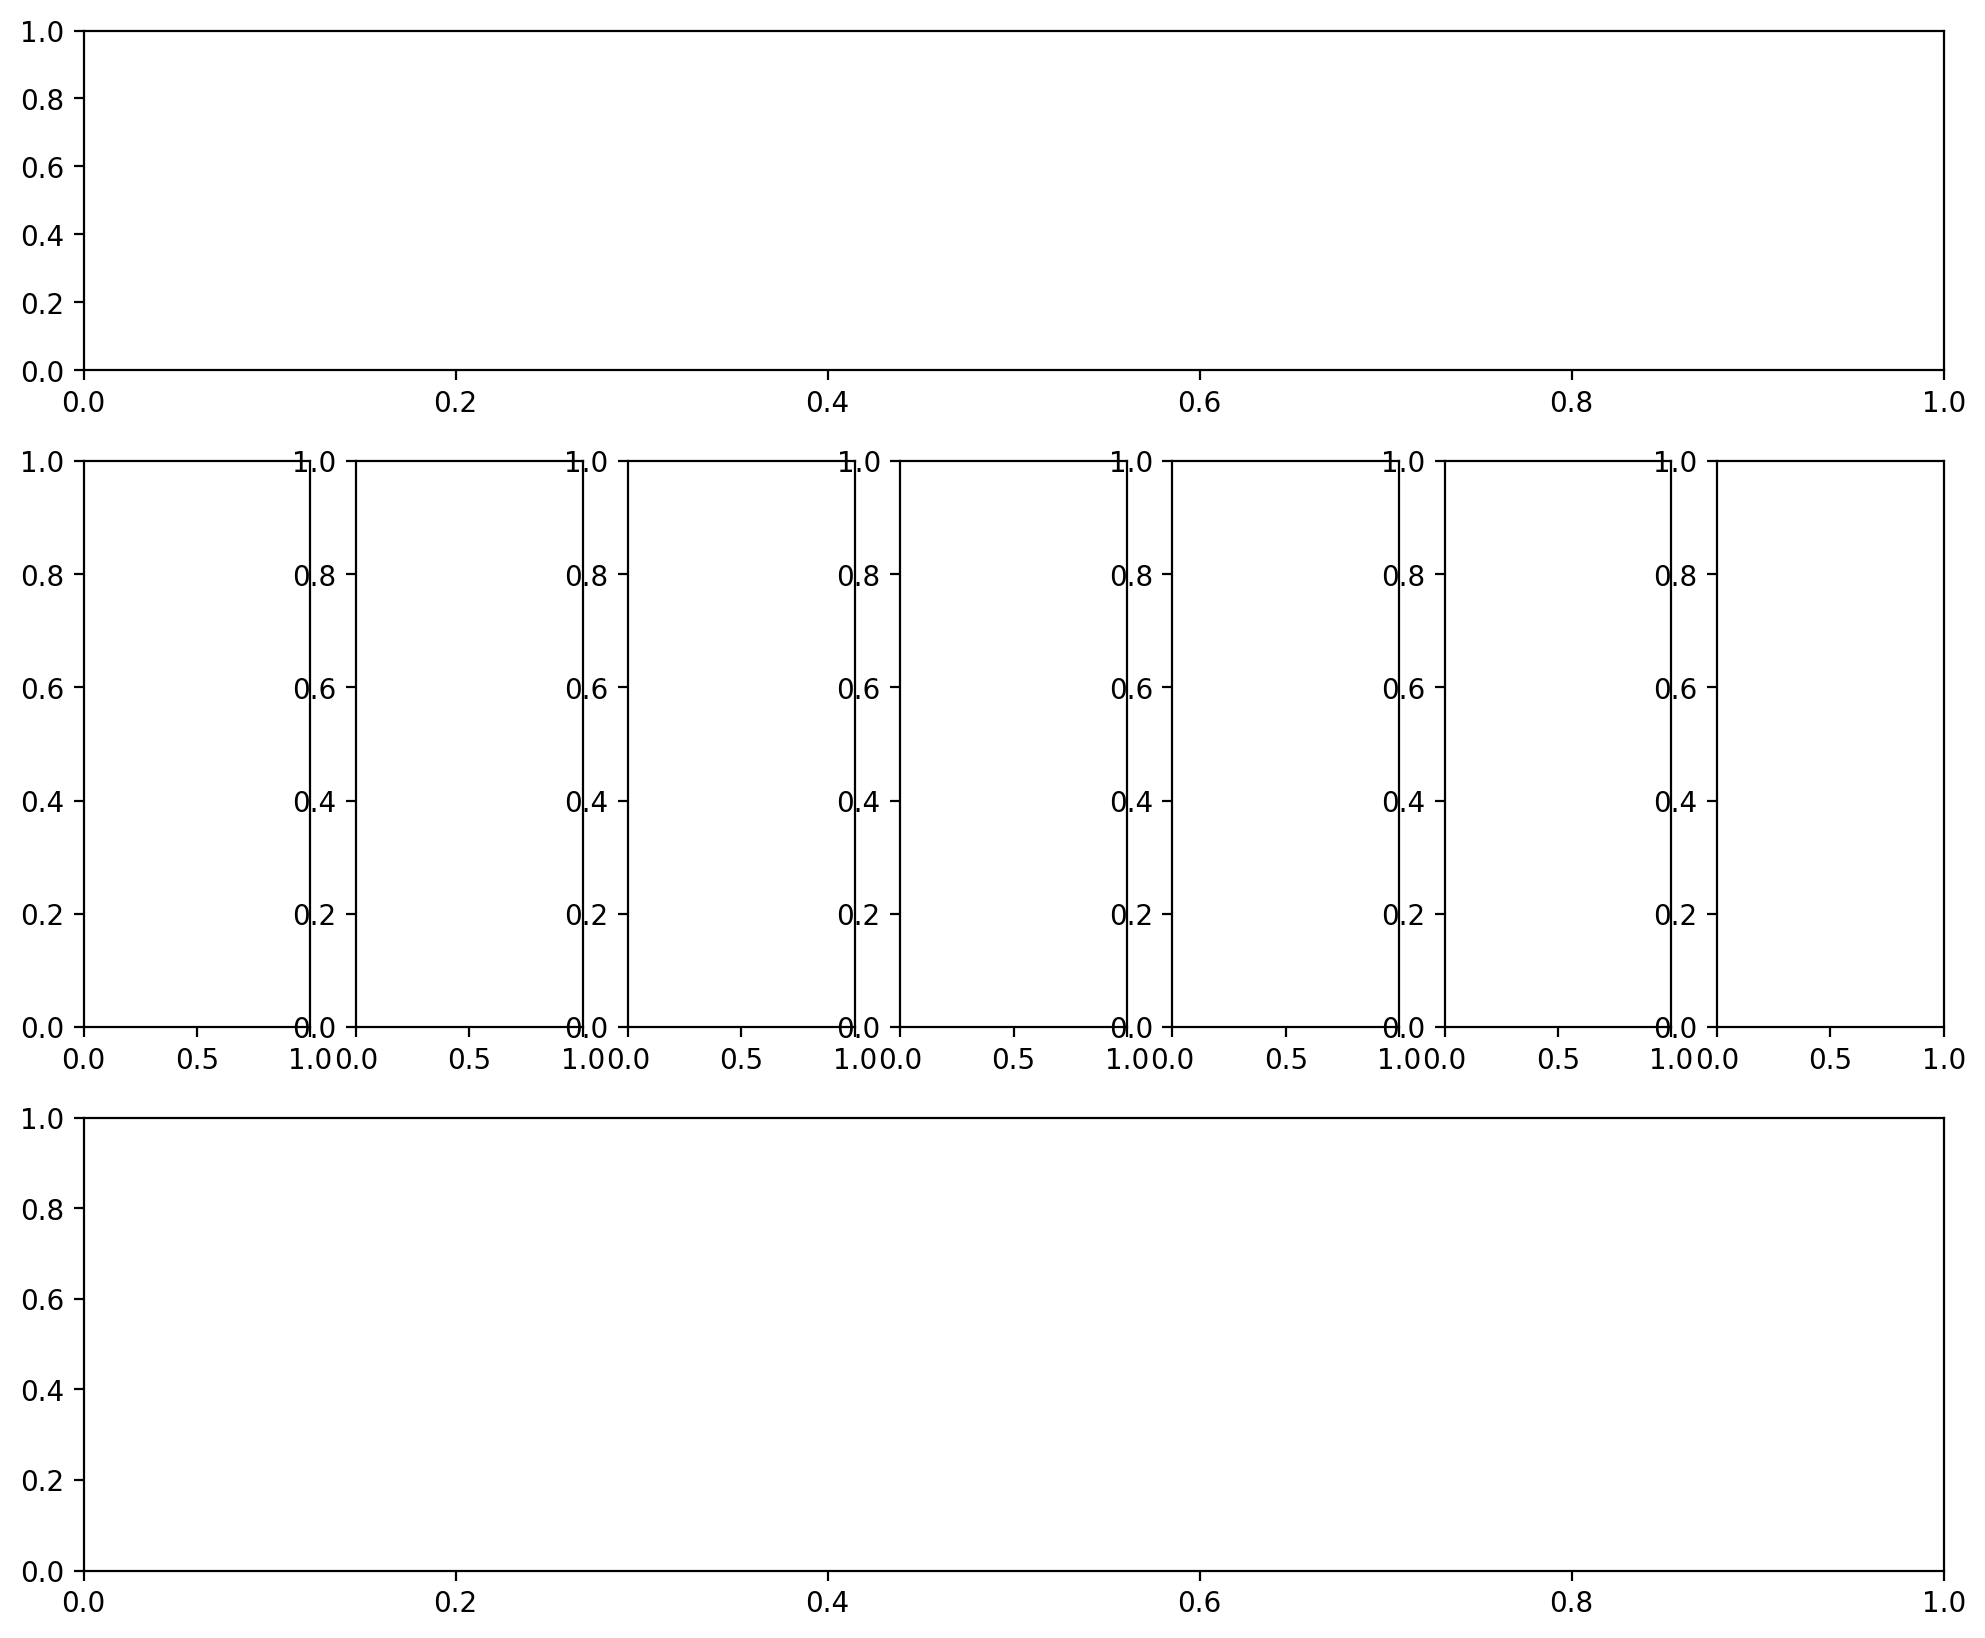

In [73]:
gs = gridspec.GridSpec(3,7, height_ratios = [0.6,1,0.8]) 
fig = plt.figure(figsize = (12,10),dpi = 200)
ax0, ax1, ax2, ax3, ax4, ax4b,ax5,ax6,ax7 = plt.subplot(gs[0,:]), plt.subplot(gs[1,0]), plt.subplot(gs[1,1]), plt.subplot(gs[1,2]),plt.subplot(gs[1,3]),plt.subplot(gs[1,4]),plt.subplot(gs[1,5]),plt.subplot(gs[1,6]),plt.subplot(gs[2,:])

yt_ocean = cc.querying.getvar(control, 'yt_ocean',master_session, n=1, ncfile = 'ocean_grid.nc')
xt_ocean = cc.querying.getvar(control, 'xt_ocean',master_session, n=1, ncfile = 'ocean_grid.nc')
yt_ocean = yt_ocean.sel(yt_ocean=lat_range)

age_plot = (bottom_age_basal-bottom_age_ctrl).plot(ax = ax0, cmap = cm.cm.balance, vmax = 3, vmin = -3,add_colorbar = False)
cax = plt.axes([0.91,0.73,0.01,0.15])
plt.colorbar(age_plot, cax = cax, label = 'age anomaly (years)')
ax0.contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport.values)+np.abs(mask_y_transport.values),colors = 'k')

ax0.vlines([-280,-200,-150,-100,-65,0,80],-82,-58,  color = 'grey')
ax0.text(-240, -80, 'Adelie', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax0.text(-175, -80, 'Ross', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax0.text(-125, -80, 'Amundsen', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax0.text(-84, -80, 'Bellings-\nhausen', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax0.text(-33, -80, 'Weddell', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax0.text(40, -80, 'Prydz', horizontalalignment='center',verticalalignment='center',fontsize = 11)

# make a fake object for legend, out of the domain
ax0.plot([0,1],[0,1],color = 'k', linewidth = 2,label = '1000m isobath contour')

ax0.set_title('(a) Ideal age anomaly of BasalGadeBrine - control', fontsize = 14)
ax0.set_ylabel('Latitude ($^\circ$N)', fontsize = 12)
ax0.set_xlabel('Longitude', fontsize = 12)
ax0.set_xticks(np.array([-240,-180,-120,-60,0,60]))
ax0.set_xticklabels(('120$^\circ$E','180$^\circ$W','120$^\circ$W','60$^\circ$W','0$^\circ$','60$^\circ$E'))
ax0.legend(loc = 'upper right')
ax0.set_ylim(min(yt_ocean.values),max(yt_ocean.values))

save_dir = '/g/data/x77/cy8964/basal_mom5-collaborative-project/notebooks/cross_contour/'

for n in np.arange(7):
    #print(n)
    ax = [ax1,ax2,ax3,ax4,ax4b,ax5,ax6][n]
    sector = [slice(0,6002),Adelie, Ross, Am,Be, Weddell, Prydz][n]
    sector_name = ['(b) Circumpolar','(c) Adelie', '(d) Ross', '(e) Amundsen','(f) Bellings-\n hausen', '(g) Weddell', '(h) Prydz'][n]
    for i in np.arange(4):
        ekey = keys[i]
        label = exptdict[ekey]['shortname']
        Nice_label = ekey
        # OPEN FROM SAVED ARRAY
        array = xr.open_dataset(save_dir+label+'_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
        color = exptdict[ekey]['colors']
        linestyle = exptdict[ekey]['linestyles']
        linewidth = exptdict[ekey]['linewidth']
        b = (array/1e6).sel(contour_index = sector).sum('contour_index')
        (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(ax = ax, y = 'isopycnal_bins', label = Nice_label,color = color, linestyle = linestyle, linewidth = linewidth)
        print(sector_name, (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).idxmax('isopycnal_bins').values)
    ax.set_ylim(1028.0,1027)
    ax.set_title(sector_name, fontsize = 14)
    ax.grid()
    if n == 0:
        ax.set_ylabel('$\sigma_0$ (kg/m$^3$)', fontsize = 13)
    else:
        ax.set_ylabel('')
        ax.set_yticklabels('')
    if n ==2:
        ax.set_xlabel('                    Cumulatively integrated cross-1000m isobath transport (Sv)', fontsize = 13)  
    else:
        ax.set_xlabel('')
    if n ==6:
        ax.legend(loc = 'upper left', bbox_to_anchor = (-0.75,1))

density_sliceAde = slice(1027.69,1030)
density_sliceRos = slice(1027.82,1030)
density_sliceAmBe = slice(1027.79,1030)
density_sliceWe = slice(1027.72,1030)
density_slicePr = slice(1027.65,1030)

for i in np.arange(4):
    ekey = keys[i]
    label = exptdict[ekey]['shortname']
    Nice_label = ekey 
    # OPEN FROM SAVED ARRAY
    array = xr.open_dataset(save_dir+label+'_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
    color = exptdict[ekey]['colors']
    linestyle = exptdict[ekey]['linestyles']
    offset = [0,-0.4,0,0][i]
    linewidth = exptdict[ekey]['linewidth']
    #copy array so we can fill it with values from the different density bins for different Antarctic sectors
    array_copy = xr.zeros_like(array.isel(isopycnal_bins = 0))
    for j in np.arange(len(array_copy)):
        if j <= 1270: #border of Adelie and Ross
            array_copy[j] = (10**(-6)*array.sel(isopycnal_bins = density_sliceAde)).sum('isopycnal_bins').values[j]            
        if j <= 2149: #border between Ross and Amundsen
            array_copy[j] = (10**(-6)*array.sel(isopycnal_bins = density_sliceRos)).sum('isopycnal_bins').values[j]
        elif j <= 3338: #border between Bellingshausen and Weddell
            array_copy[j] = (10**(-6)*array.sel(isopycnal_bins = density_sliceAmBe)).sum('isopycnal_bins').values[j]
        elif j <=4798: #border between weddell and prydz
            array_copy[j] = (10**(-6)*array.sel(isopycnal_bins = density_sliceWe)).sum('isopycnal_bins').values[j]
        else:
            array_copy[j] = (10**(-6)*array.sel(isopycnal_bins = density_slicePr)).sum('isopycnal_bins').values[j]
    
    ax7.plot(distance_along_contour,array_copy.cumsum('contour_index'),label = Nice_label, color = color, linestyle = linestyle, linewidth = linewidth)
    ax7.text(distance_along_contour[-1]+0.2,offset + array_copy.cumsum('contour_index')[-1],
             "{:.2f}".format(array_copy.cumsum('contour_index')[-1].values) + ' Sv', color = color)
ax7.set_ylabel('Cumulative \n transport (Sv)', fontsize = 12)
ax7.set_xticks(distance_along_contour[distance_indices.astype(int)[:-1]])
ax7.set_xticklabels(('80$^\circ$E','120$^\circ$E','180$^\circ$W','120$^\circ$W','60$^\circ$W','0$^\circ$','60$^\circ$E'));
ax7.set_xlim(0,distance_along_contour[-1]);
ax7.set_xlabel('Distance along contour (labelled by longitude)', fontsize = 12)

inds= [1270, 2149,  3338, 4798]
ax7.vlines(distance_along_contour[inds],-2,11.2,  color = 'grey',linewidth = 3)
inds= [2803]
ax7.vlines(distance_along_contour[inds],-2,11.2,  color = 'grey',linewidth = 0.5)


# region labels
ax7.text(distance_along_contour[635], 10.4, 'Adelie', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[1709], 10.4, 'Ross', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[2500], 10.4, 'Amundsen', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[3050], 10.1, 'Bellings-\nhausen', horizontalalignment='center',verticalalignment='center',fontsize = 10)
ax7.text(distance_along_contour[3900], 10.4, 'Weddell', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[5399], 10.4, 'Prydz', horizontalalignment='center',verticalalignment='center',fontsize = 11)

#density bin labels
ax7.text(distance_along_contour[20], -1.1, '$\sigma_0>1027.69$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[1290], -1.1, '$\sigma_0>1027.82$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[2170], -1.1, '$\sigma_0>1027.79$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[3360], -1.1, '$\sigma_0>1027.72$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[4820], -1.1, '$\sigma_0>1027.65$', horizontalalignment='left',verticalalignment='center',fontsize = 9)


ax7.set_ylim(-1.5,11.2)
ax7.grid(axis = 'y')
ax7.legend(loc = 'upper left',fontsize = 11, ncol=2, bbox_to_anchor = (0,0.9))
ax7.set_title('(i) 3-year mean Dense Shelf Water export over 1000m isobath',fontsize = 14)

fig.subplots_adjust(hspace = 0.43, wspace = 0.15)

Adjusted density slices in above to match max of values printed out, which is density of maximum cumulative transport (figs b-h) for each experiment. This way we don't pick up returning CDW (except for sub-basin variability e.g. Weddell)

# Plot rearranging and styling

NameError: name 'cc' is not defined

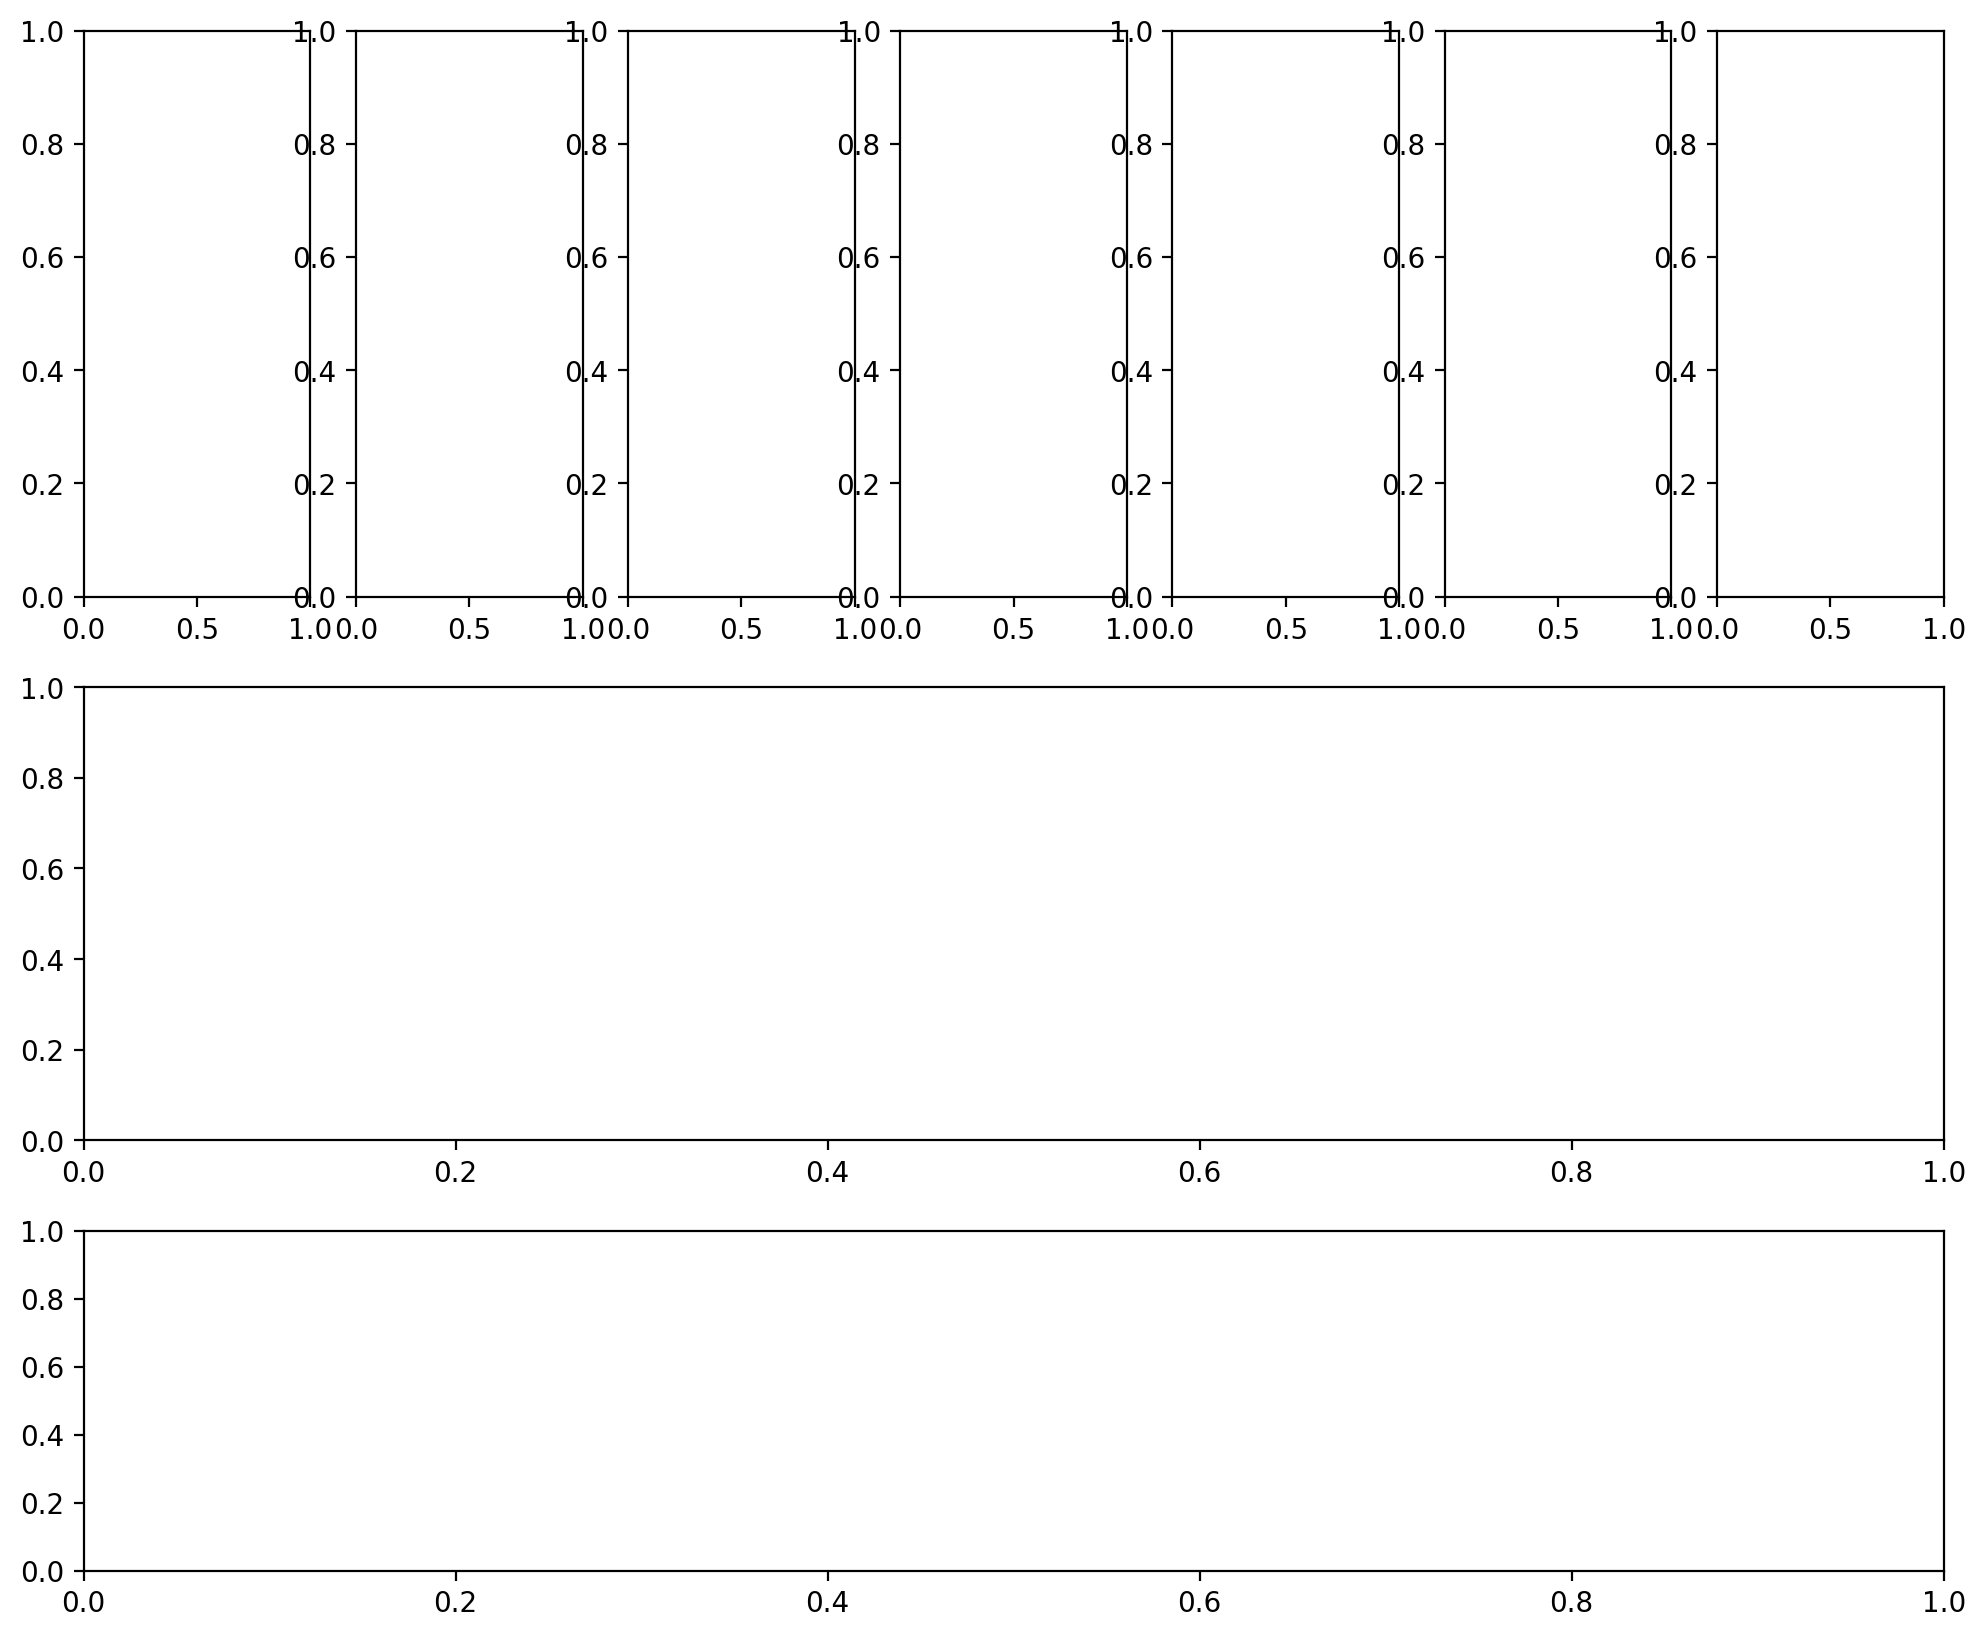

In [74]:
gs = gridspec.GridSpec(3,7, height_ratios = [1,0.8,0.6]) 
fig = plt.figure(figsize = (12,10),dpi = 200)
ax0, ax1, ax2, ax3, ax4, ax4b,ax5,ax6,ax7 = plt.subplot(gs[2,:]), plt.subplot(gs[0,0]), plt.subplot(gs[0,1]), plt.subplot(gs[0,2]),plt.subplot(gs[0,3]),plt.subplot(gs[0,4]),plt.subplot(gs[0,5]),plt.subplot(gs[0,6]),plt.subplot(gs[1,:])

yt_ocean = cc.querying.getvar(control, 'yt_ocean',master_session, n=1, ncfile = 'ocean_grid.nc')
xt_ocean = cc.querying.getvar(control, 'xt_ocean',master_session, n=1, ncfile = 'ocean_grid.nc')
yt_ocean = yt_ocean.sel(yt_ocean=lat_range)

age_plot = (bottom_age_basal-bottom_age_ctrl).plot(ax = ax0, cmap = cm.cm.balance, vmax = 1.5, vmin = -1.5,add_colorbar = False)
cax = plt.axes([0.91,0.11,0.01,0.15])
plt.colorbar(age_plot, cax = cax, label = 'bottom age anomaly (years)',extend = 'both')
ax0.contour(xt_ocean.values, yt_ocean.values,np.abs(mask_x_transport.values)+np.abs(mask_y_transport.values),colors = 'k')
ax0.contourf(ht.xt_ocean, land_mask_lat,land_mask_masked,colors='dimgrey',zorder=2,)

ax0.vlines([-280,-200,-150,-100,-65,0,80],-82,-58,  color = 'grey')
ax0.text(-240, -81, 'Adelie', horizontalalignment='center',verticalalignment='bottom',fontsize = 11,color = 'w')
ax0.text(-175, -81, 'Ross', horizontalalignment='center',verticalalignment='bottom',fontsize = 11,color = 'w')
ax0.text(-125, -81, 'Amundsen', horizontalalignment='center',verticalalignment='bottom',fontsize = 11,color = 'w')
ax0.text(-84, -81, 'Bellings-\nhausen', horizontalalignment='center',verticalalignment='bottom',fontsize = 11,color = 'w')
ax0.text(-33, -81, 'Weddell', horizontalalignment='center',verticalalignment='bottom',fontsize = 11,color = 'w')
ax0.text(40, -81, 'Prydz', horizontalalignment='center',verticalalignment='bottom',fontsize = 11,color = 'w')

# make a fake object for legend, out of the domain
ax0.plot([0,1],[0,1],color = 'k', linewidth = 2,label = '1000m isobath contour')

ax0.set_title('(i) Ideal bottom age anomaly of BasalGadeBrine - control', fontsize = 14)
ax0.set_ylabel('Latitude ($^\circ$N)', fontsize = 12)
ax0.set_xlabel('Longitude', fontsize = 12)
ax0.set_xticks(np.array([-240,-180,-120,-60,0,60]))
ax0.set_xticklabels(('120$^\circ$E','180$^\circ$W','120$^\circ$W','60$^\circ$W','0$^\circ$','60$^\circ$E'))
ax0.legend(loc = 'upper right')
ax0.set_ylim(min(yt_ocean.values),max(yt_ocean.values))

save_dir = '/g/data/x77/cy8964/basal_mom5-collaborative-project/notebooks/cross_contour/'

for n in np.arange(7):
    #print(n)
    ax = [ax1,ax2,ax3,ax4,ax4b,ax5,ax6][n]
    sector = [slice(0,6002),Adelie, Ross, Am,Be, Weddell, Prydz][n]
    sector_name = ['(a) Circumpolar','(b) Adelie', '(c) Ross', '(d) Amundsen','(e) Bellings-\n hausen', '(f) Weddell', '(g) Prydz'][n]
    for i in np.arange(4):
        ekey = keys[i]
        label = exptdict[ekey]['shortname']
        Nice_label = ekey
        # OPEN FROM SAVED ARRAY
        array = xr.open_dataset(save_dir+label+'_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
        color = exptdict[ekey]['colors']
        linestyle = exptdict[ekey]['linestyles']
        linewidth = exptdict[ekey]['linewidth']
        b = (array/1e6).sel(contour_index = sector).sum('contour_index')
        (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).plot(ax = ax, y = 'isopycnal_bins', label = Nice_label,color = color, linestyle = linestyle, linewidth = linewidth)
        print(sector_name, (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).idxmax('isopycnal_bins').values)
    ax.set_ylim(1028.0,1027)
    ax.set_title(sector_name, fontsize = 14, y = 1.06, va = 'center')
    ax.grid()
    if n == 0:
        ax.set_ylabel('$\sigma_0$ (kg/m$^3$)', fontsize = 13)
    else:
        ax.set_ylabel('')
        ax.set_yticklabels('')
    if n ==2:
        ax.set_xlabel('                                             Cumulatively integrated cross-1000m isobath transport (Sv)', fontsize = 13)  
    else:
        ax.set_xlabel('')
    if n ==6:
        ax.legend(loc = 'upper left', bbox_to_anchor = (-0.75,1))

density_sliceAde = slice(1027.69,1030)
density_sliceRos = slice(1027.82,1030)
density_sliceAmBe = slice(1027.79,1030)
density_sliceWe = slice(1027.72,1030)
density_slicePr = slice(1027.65,1030)

for i in np.arange(4):
    ekey = keys[i]
    label = exptdict[ekey]['shortname']
    Nice_label = ekey 
    # OPEN FROM SAVED ARRAY
    array = xr.open_dataset(save_dir+label+'_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
    color = exptdict[ekey]['colors']
    linestyle = exptdict[ekey]['linestyles']
    offset = [0,-0.4,0,0][i]
    linewidth = exptdict[ekey]['linewidth']
    #copy array so we can fill it with values from the different density bins for different Antarctic sectors
    array_copy = xr.zeros_like(array.isel(isopycnal_bins = 0))
    for j in np.arange(len(array_copy)):
        if j <= 1270: #border of Adelie and Ross
            array_copy[j] = (10**(-6)*array.sel(isopycnal_bins = density_sliceAde)).sum('isopycnal_bins').values[j]            
        if j <= 2149: #border between Ross and Amundsen
            array_copy[j] = (10**(-6)*array.sel(isopycnal_bins = density_sliceRos)).sum('isopycnal_bins').values[j]
        elif j <= 3338: #border between Bellingshausen and Weddell
            array_copy[j] = (10**(-6)*array.sel(isopycnal_bins = density_sliceAmBe)).sum('isopycnal_bins').values[j]
        elif j <=4798: #border between weddell and prydz
            array_copy[j] = (10**(-6)*array.sel(isopycnal_bins = density_sliceWe)).sum('isopycnal_bins').values[j]
        else:
            array_copy[j] = (10**(-6)*array.sel(isopycnal_bins = density_slicePr)).sum('isopycnal_bins').values[j]
    
    ax7.plot(distance_along_contour,array_copy.cumsum('contour_index'),label = Nice_label, color = color, linestyle = linestyle, linewidth = linewidth)
    ax7.text(distance_along_contour[-1]+0.2,offset + array_copy.cumsum('contour_index')[-1],
             "{:.2f}".format(array_copy.cumsum('contour_index')[-1].values) + ' Sv', color = color)
ax7.set_ylabel('Cumulative \n transport (Sv)', fontsize = 12)
ax7.set_xticks(distance_along_contour[distance_indices.astype(int)[:-1]])
ax7.set_xticklabels(('80$^\circ$E','120$^\circ$E','180$^\circ$W','120$^\circ$W','60$^\circ$W','0$^\circ$','60$^\circ$E'));
ax7.set_xlim(0,distance_along_contour[-1]);
ax7.set_xlabel('Distance along contour (labelled by longitude)', fontsize = 12)

inds= [1270, 2149,  3338, 4798]
ax7.vlines(distance_along_contour[inds],-2,11.2,  color = 'grey',linewidth = 3)
inds= [2803]
ax7.vlines(distance_along_contour[inds],-2,11.2,  color = 'grey',linewidth = 0.5)


# region labels
ax7.text(distance_along_contour[635], 10.4, 'Adelie', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[1709], 10.4, 'Ross', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[2500], 10.4, 'Amundsen', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[3050], 10.1, 'Bellings-\nhausen', horizontalalignment='center',verticalalignment='center',fontsize = 10)
ax7.text(distance_along_contour[3900], 10.4, 'Weddell', horizontalalignment='center',verticalalignment='center',fontsize = 11)
ax7.text(distance_along_contour[5399], 10.4, 'Prydz', horizontalalignment='center',verticalalignment='center',fontsize = 11)

#density bin labels
ax7.text(distance_along_contour[20], -1.1, '$\sigma_0>1027.69$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[1290], -1.1, '$\sigma_0>1027.82$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[2170], -1.1, '$\sigma_0>1027.79$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[3360], -1.1, '$\sigma_0>1027.72$', horizontalalignment='left',verticalalignment='center',fontsize = 9)
ax7.text(distance_along_contour[4820], -1.1, '$\sigma_0>1027.65$', horizontalalignment='left',verticalalignment='center',fontsize = 9)


ax7.set_ylim(-1.5,11.2)
ax7.grid(axis = 'y')
ax7.legend(loc = 'upper left',fontsize = 11, ncol=2, bbox_to_anchor = (0,0.9))
ax7.set_title('(h) 3-year mean Dense Shelf Water export over 1000m isobath',fontsize = 14)

fig.subplots_adjust(hspace = 0.43, wspace = 0.15)

# Print peak circumpolar transport

In [114]:
sector = slice(0,6002)
for i in np.arange(4):
    ekey = keys[i]
    label = exptdict[ekey]['shortname']
    Nice_label = ekey
    # OPEN FROM SAVED ARRAY
    array = xr.open_dataset(save_dir+label+'_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
    color = exptdict[ekey]['colors']
    linestyle = exptdict[ekey]['linestyles']
    linewidth = exptdict[ekey]['linewidth']
    b = (array/1e6).sel(contour_index = sector).sum('contour_index')
    if i==0:
        control_maxot = (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).max('isopycnal_bins').values
        control_maxotgt10278 = (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).sel(isopycnal_bins = slice(1027.8,1029)).max('isopycnal_bins').values

        print(label, ': max overturning = ', (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).max('isopycnal_bins').values, 'Sv')
        print(label, ': max overturning at densities greater than 1027.8 = ', (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).sel(isopycnal_bins = slice(1027.8,1029)).max('isopycnal_bins').values, 'Sv')
    else:
        print(label, ': max overturning = ', (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).max('isopycnal_bins').values, 'Sv', 
              'This is ',(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).max('isopycnal_bins').values/control_maxot*100,'% of control')
        print(label, ': max overturning at densities greater than 1027.8 = ', (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).sel(isopycnal_bins = slice(1027.8,1029)).max('isopycnal_bins').values, 'Sv', 
              'This is ',(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).sel(isopycnal_bins = slice(1027.8,1029)).max('isopycnal_bins').values/control_maxotgt10278*100,'% of control')
        
    print('----')


control : max overturning =  [4.20365645 0.        ] Sv
control : max overturning at densities greater than 1027.8 =  [3.14116921 0.        ] Sv
----
control_sofia : max overturning =  [6.17575653 0.        ] Sv This is  [146.91392139          nan] % of control
control_sofia : max overturning at densities greater than 1027.8 =  [3.20799535 0.        ] Sv This is  [102.12742877          nan] % of control
----
control_antwater : max overturning =  [3.05238889 0.        ] Sv This is  [72.6127105        nan] % of control
control_antwater : max overturning at densities greater than 1027.8 =  [-2.77555756e-17  0.00000000e+00] Sv This is  [-8.83606509e-16             nan] % of control
----
basal_gade_brine : max overturning =  [6.21157765 0.        ] Sv This is  [147.76606319          nan] % of control
basal_gade_brine : max overturning at densities greater than 1027.8 =  [5.97845535 0.        ] Sv This is  [190.32579733          nan] % of control
----


# Print peak Adelie and Ross transport

In [41]:
for j in np.arange(2):
    sector = [Adelie, Ross][j]
    label = ['Adelie','Ross'][j]
    print('-----',label,'-----')
    for i in np.arange(4):
        ekey = keys[i]
        label = exptdict[ekey]['shortname']
        Nice_label = ekey
        # OPEN FROM SAVED ARRAY
        array = xr.open_dataset(save_dir+label+'_vol_trans_across_contour_binned_last_3yr.nc').vol_trans_across_contour_binned_last_3yr
        color = exptdict[ekey]['colors']
        linestyle = exptdict[ekey]['linestyles']
        linewidth = exptdict[ekey]['linewidth']
        b = (array/1e6).sel(contour_index = sector).sum('contour_index')
        if i==0:
            control_maxot = (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).max('isopycnal_bins').values
#            control_maxotgt10278 = (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).sel(isopycnal_bins = slice(1027.8,1029)).max('isopycnal_bins').values
    
            print(label, ': max overturning = ', (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).max('isopycnal_bins').values, 'Sv')
#            print(label, ': max overturning at densities greater than 1027.8 = ', (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).sel(isopycnal_bins = slice(1027.8,1029)).max('isopycnal_bins').values, 'Sv')
        else:
            print(label, ': max overturning = ', (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).max('isopycnal_bins').values, 'Sv', 
                  'This is ',(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).max('isopycnal_bins').values/control_maxot*100,'% of control')
            # print(label, ': max overturning at densities greater than 1027.8 = ', (b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).sel(isopycnal_bins = slice(1027.8,1029)).max('isopycnal_bins').values, 'Sv', 
            #       'This is ',(b.sum('isopycnal_bins') -b.cumsum('isopycnal_bins')).sel(isopycnal_bins = slice(1027.8,1029)).max('isopycnal_bins').values/control_maxotgt10278*100,'% of control')
            
        print('----')


----- Adelie -----
control : max overturning =  1.3731829398679363 Sv
----
basal_nogade : max overturning =  1.2805970359028493 Sv This is  93.25756960146975 % of control
----
basal : max overturning =  1.952287693018551 Sv This is  142.17244012704595 % of control
----
basal_gade_brine : max overturning =  1.7090637848401955 Sv This is  124.46002169270776 % of control
----
----- Ross -----
control : max overturning =  3.7150914580561483 Sv
----
basal_nogade : max overturning =  3.767983466266025 Sv This is  101.42370675949796 % of control
----
basal : max overturning =  4.1804688584721585 Sv This is  112.52667412552772 % of control
----
basal_gade_brine : max overturning =  4.278899831694238 Sv This is  115.17616403266399 % of control
----


# Back of the envelope calculation of age change

In [54]:
# open basal transport
start_time = '1907-01-01'
end_time = '1909-12-31'
time_slice = slice(start_time,end_time)

basal_fwflx = cc.querying.getvar(basal_gade_brine, 'basal_fwflx',basal_melt_session,start_time = start_time,
                            end_time = end_time).sel(time = time_slice,yt_ocean=lat_range)
area_t = cc.querying.getvar(basal_gade_brine, 'area_t',basal_melt_session,n=-1)

def shelf_mask_isobath(var):
    '''
    Masks ACCESS-OM2-01 variables by the region polewards of the 1000m isobath as computed using 
    a script contributed by Adele Morrison.
    Only to be used with ACCESS-OM2-0.1 output!
    '''
    contour_file = np.load('/g/data/ik11/grids/Antarctic_slope_contour_1000m.npz')
    
    shelf_mask = contour_file['contour_masked_above']
    yt_ocean = contour_file['yt_ocean']
    xt_ocean = contour_file['xt_ocean']
    
    # in this file the points along the isobath are given a positive value, the points outside (northwards) 
    # of the isobath are given a value of -100 and all the points on the continental shelf have a value of 0 
    # so we mask for the 0 values 
    shelf_mask[np.where(shelf_mask!=0)] = np.nan
    shelf_mask = shelf_mask+1
    shelf_map  = np.nan_to_num(shelf_mask)
    shelf_mask = xr.DataArray(shelf_mask, coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])
    shelf_map  = xr.DataArray(shelf_map,  coords = [('yt_ocean', yt_ocean), ('xt_ocean', xt_ocean)])
    
    # then we want to multiply the variable with the mask so we need to account for the shape of the mask. 
    # The mask uses a northern cutoff of 59S.
    masked_var = var.sel(yt_ocean = slice(-90, -59.03)) * shelf_mask

    return masked_var, shelf_map
    
masked_area, shelf_map, = shelf_mask_isobath(area_t)

In [71]:
# compute area of Antarctic shelf ocean from area*max depth
(masked_area*ht).sum().values 

array(1.3999135e+15, dtype=float32)

In [72]:
# compute mass added in 10 years from intregral of basal_fwflux of 1 year *10 years * s_per_month*area basal is added to
(basal_fwflx.isel(time = np.arange(12))*masked_area).sum().values*30*24*3600*10 #kg/m^3 * m^3

1.42017712128e+16

In [76]:
vol_basal_fwflx = 1.42017712128e16/1030 #m^3/10yr

In [77]:
vol_shelf = 1.3999135e15 #m^3

In [78]:
vol_basal_fwflx/vol_shelf

0.009849270966433255

Suggests 1% of continetal shelf water by volume comes from basal melt if all is added to shelf and nothing lost. Assuming all of this zero age goes to the bottom, that would indicate 1% ish less age than normal. Clearly our age changes are bigger than that (~1 year anomaly over 10 year run) so age changes dominanted by circulation changes rather than simply adding volume.

